# Code Notebook 3.2

AP Measures

Tristan Muno [](https://orcid.org/0009-0002-3078-8436) (University of Mannheim)  
Thomas König [](https://orcid.org/0000-0002-1797-6662) (University of Mannheim)  
February 11, 2026

# Setup

In [ ]:

# To track render duration
start_time <- Sys.time()

# set width of console output
options(width = 80)


# Install and load required packages
p_required <- c(
  "tidyverse",
  "here",
  "ggpubr", # theme_pubr()
  "sessioninfo"
)
packages <- rownames(installed.packages())
p_to_install <- p_required[!(p_required %in% packages)]
if (length(p_to_install) > 0) {
  install.packages(p_to_install)
}
sapply(p_required, require, character.only = TRUE)


Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: here

here() starts at C:/R/research/CSAP

Loading required package: ggpubr

Loading required package: sessioninfo

  tidyverse        here      ggpubr sessioninfo 
       TRUE        TRUE        TRUE        TRUE 

# Load Data

In [ ]:

eu25games2019 <- readRDS(
  file = here(
    "data",
    "03_final",
    "eu25games2019.rds"
  )
)


# Overview of Measures

For our behavioral experiment, we conceptually draw from Reiljan’s API. Formally, we define AP as the difference in tokens allocated to the ingroup, minus the average number of tokens allocated to all outgroups.

Weighted and unweighted

For the thermometer score, we calculate three measures, each weighted and unweighted:

Reiljan API Wagner Mean Distance Wagner Spread of Scores

We compare the levels across identifiers, voters (without identity) and nonpartisans (Wagner)

# Party sizes (for weighting)

What to use, empirical distributions in sample (id/vote?) or electoral vote share in 2019? Both?

In [ ]:

# relative (reported) vote shares
votes_per_country <- eu25games2019 |>
  select(
    meta_country,
    meta_pid,
    der_vote_combined_name
  ) |>
  distinct(meta_pid, .keep_all = T) |>
  filter(
    der_vote_combined_name != "dont-know" &
      der_vote_combined_name != "other"
  ) |>
  group_by(meta_country, der_vote_combined_name) |>
  count(der_vote_combined_name) |>
  ungroup() |>
  group_by(meta_country) |>
  summarise(
    abs_vote = sum(n)
  )

votes_per_party <- eu25games2019 |>
  select(
    meta_country,
    meta_pid,
    der_vote_combined_name
  ) |>
  distinct(meta_pid, .keep_all = T) |>
  filter(
    der_vote_combined_name != "dont-know" &
      der_vote_combined_name != "other"
  ) |>
  group_by(meta_country, der_vote_combined_name) |>
  count(der_vote_combined_name) |>
  ungroup()

votes_per_party <- votes_per_party |>
  left_join(
    votes_per_country,
    by = join_by(meta_country)
  )

votes_per_party <- votes_per_party |>
  mutate(
    der_anchor_vote_share = n / abs_vote
  )

eu25games2019 <- eu25games2019 |>
  left_join(
    (votes_per_party |>
      select(
        der_vote_combined_name,
        der_anchor_vote_share
      )),
    by = join_by(der_partisan_anchor == der_vote_combined_name)
  )


# Target Table (Pooled Descriptive Analyses)

What I want is a tibble in the format (or do I?)

| Measurement | measure    | weighted | der_partisan_type |  ap | ci_low | ci_high |
|:------------|:-----------|:---------|:------------------|----:|-------:|--------:|
| Behavioral  | API        | N        | Explicit          |   X |      X |       X |
| Behavioral  | API        | N        | Implicit          |   X |      X |       X |
| Behavioral  | API        | N        | Total             |   X |      X |       X |
| Behavioral  | API        | Y        | Explicit          |   X |      X |       X |
| Behavioral  | API        | Y        | Implicit          |   X |      X |       X |
| Behavioral  | API        | Y        | Total             |   X |      X |       X |
| Attitudinal | API        | N        | Explicit          |   X |      X |       X |
| Attitudinal | API        | N        | Implicit          |   X |      X |       X |
| Attitudinal | API        | N        | Total             |   X |      X |       X |
| Attitudinal | API        | Y        | Explicit          |   X |      X |       X |
| Attitudinal | API        | Y        | Implicit          |   X |      X |       X |
| Attitudinal | API        | Y        | Total             |   X |      X |       X |
| Attitudinal | Mean Dist. | N        | Explicit          |   X |      X |       X |
| Attitudinal | Mean Dist. | N        | Implicit          |   X |      X |       X |
| Attitudinal | Mean Dist. | N        | None              |   X |      X |       X |
| Attitudinal | Mean Dist. | N        | Total             |   X |      X |       X |
| Attitudinal | Mean Dist. | Y        | Explicit          |   X |      X |       X |
| Attitudinal | Mean Dist. | Y        | Implicit          |   X |      X |       X |
| Attitudinal | Mean Dist. | Y        | None              |   X |      X |       X |
| Attitudinal | Mean Dist. | Y        | Total             |   X |      X |       X |
| Attitudinal | Spread     | N        | Explicit          |   X |      X |       X |
| Attitudinal | Spread     | N        | Implicit          |   X |      X |       X |
| Attitudinal | Spread     | N        | None              |   X |      X |       X |
| Attitudinal | Spread     | N        | Total             |   X |      X |       X |
| Attitudinal | Spread     | Y        | Explicit          |   X |      X |       X |
| Attitudinal | Spread     | Y        | Implicit          |   X |      X |       X |
| Attitudinal | Spread     | Y        | None              |   X |      X |       X |
| Attitudinal | Spread     | Y        | Total             |   X |      X |       X |

# Aggregated AP: Token Allocation

We measure affective polarization as the difference in expected token allocations to co-partisans and out-partisans. Expectations are taken over all conjoint profiles presented to respondents, such that the out-partisan category averages across all non-anchor parties. This operationalization is conceptually equivalent to Reiljan’s affective polarization index (API), adapted to behavioral outcomes.

$$
\text{AP} = \mathbb{E}(\text{Token} \mid \text{Co}) - \mathbb{E}(\text{Token} \mid \text{Out})
$$ {#eq-eu25-ap-cj}

In [ ]:

pooled_ap_cj <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type)
  ) |>
  group_by(der_partisan_type, der_partisan_relationship) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap = mean_Co - mean_Out,
    se = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      .default = NA
    )
  )


total_pooled_ap_cj <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type)
  ) |>
  group_by(der_partisan_relationship) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap = mean_Co - mean_Out,
    se = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se
  ) |>
  mutate(der_partisan_type = "Total") |>
  relocate(der_partisan_type, .before = mean_Co)

pooled_ap_cj <- pooled_ap_cj |>
  bind_rows(total_pooled_ap_cj) |>
  mutate(measure = "Token")

pooled_ap_cj <- pooled_ap_cj |>
  select(
    der_partisan_type,
    ap,
    ci_low,
    ci_high
  ) |>
  mutate(
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    weighted = 0,
  )


To account for cross-national differences in party system composition, we compute party-specific affective polarization within each country and weight these differences by parties’ empirical vote shares in our data. Party weights sum to one within countries, ensuring that affective polarization reflects the relative electoral importance of parties in the national party system.

European affective polarization is obtained by aggregating country-level affective polarization scores. Each country contributes equally to the European estimate, preventing countries with larger samples or more fragmented party systems from exerting disproportionate influence.

$$
\text{AP}_{c}
=
\sum_{p \in c}
w_{pc}
\, \text{AP}_{pc},
\qquad
\sum_{p \in c} w_{pc} = 1
$$ {#eq-eu25-ap-country-weighted}

$$
\text{AP}_{EU}
=
\frac{1}{C}
\sum_{c=1}^{C}
\text{AP}_{c}
$$ {#eq-eu25-ap-europe}

In [ ]:

ap_country_party <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type),
    !is.na(der_anchor_vote_share)
  ) |>
  group_by(
    meta_country,
    der_partisan_type,
    der_partisan_anchor,
    der_partisan_relationship
  ) |>
  summarise(
    mean = mean(cj_token),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = mean
  ) |>
  mutate(
    ap_party = Co - Out
  )

ap_country_weighted <- eu25games2019 |>
  distinct(
    meta_country,
    der_partisan_anchor,
    der_anchor_vote_share
  ) |>
  right_join(
    ap_country_party,
    by = c("meta_country", "der_partisan_anchor")
  ) |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap_country = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),
    .groups = "drop"
  )

ap_europe <- ap_country_weighted |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    weighted = 1,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      .default = NA
    )
  ) |>
  select(
    -se
  )

# Again for total AP (no distinguishing type) ----------------------------------
ap_country_party_total <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type),
    !is.na(der_anchor_vote_share)
  ) |>
  group_by(
    meta_country,
    der_partisan_anchor,
    der_partisan_relationship
  ) |>
  summarise(
    mean = mean(cj_token),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = mean
  ) |>
  mutate(
    ap_party = Co - Out
  )

ap_country_weighted_total <- eu25games2019 |>
  distinct(
    meta_country,
    der_partisan_anchor,
    der_anchor_vote_share
  ) |>
  right_join(
    ap_country_party_total,
    by = c("meta_country", "der_partisan_anchor")
  ) |>
  group_by(meta_country) |>
  summarise(
    ap_country = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),
    .groups = "drop"
  )

ap_europe_total <- ap_country_weighted_total |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    weighted = 1,
    der_partisan_type = "Total"
  ) |>
  select(
    -se
  )

pooled_ap_cj <- pooled_ap_cj |>
  bind_rows(ap_europe, ap_europe_total)


# Aggregated AP: Thermometer Scores

In [ ]:

# turn thermoscores to long format
thermo_long <- eu25games2019 |>
  select(
    meta_country,
    meta_pid,
    der_partisan_type,
    der_partisan_anchor,
    matches("^q_thermo_[0-9]+$"),
    matches("^ext_q_thermo_[0-9]+_pf_name$")
  ) |>
  distinct(meta_pid, .keep_all = T) |>
  pivot_longer(
    cols = matches("^(q_thermo_|ext_q_thermo_)[0-9]+"),
    names_to = c(".value", "slot"),
    names_pattern = "(q_thermo|ext_q_thermo)_(\\d+)"
  ) |>
  rename(
    thermo_score = q_thermo,
    thermo_party = ext_q_thermo
  ) |>
  filter(!is.na(thermo_score), !is.na(thermo_party)) |>
  mutate(thermo_score = thermo_score / 10) |>
  select(
    meta_country,
    meta_pid,
    der_partisan_type,
    der_partisan_anchor,
    thermo_party,
    thermo_score
  )


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.

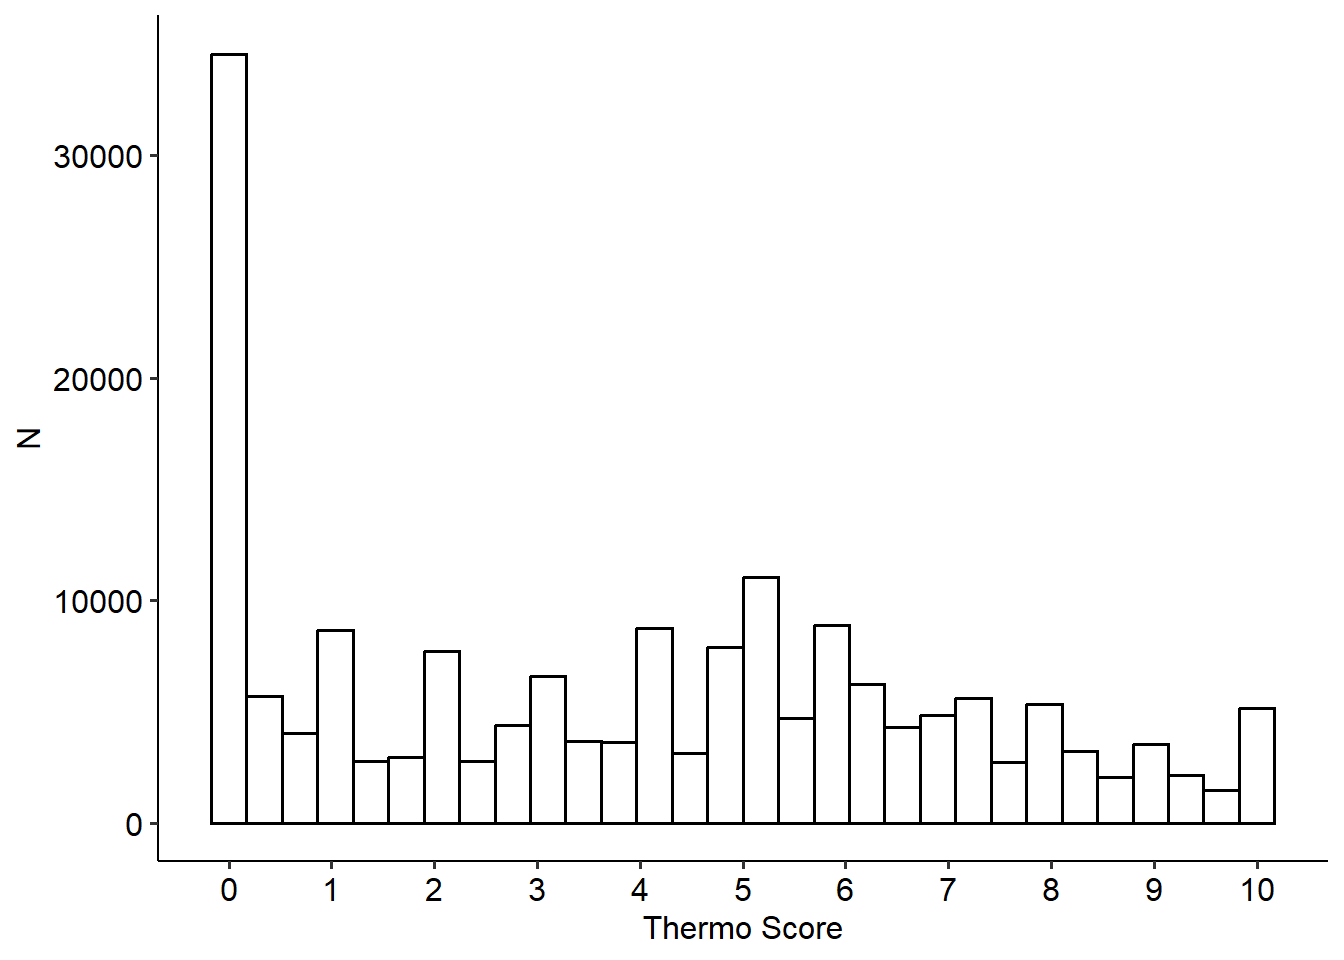

In [ ]:

summary_stats <- thermo_long |>
  summarise(
    mean_thermo = mean(thermo_score, na.rm = TRUE),
    median_thermo = median(thermo_score, na.rm = TRUE),
    sd_thermo = sd(thermo_score, na.rm = TRUE)
  )

thermo_long |>
  ggplot(
    aes(x = thermo_score)
  ) +
  geom_histogram(
    color = "black",
    fill = "white"
  ) +
  scale_x_continuous(
    breaks = 0:10,
    labels = 0:10
  ) +
  labs(
    x = "Thermo Score",
    y = "N"
  ) +
  ggpubr::theme_pubr()


There are three main operationalization strategies applied in European AP studies: Reiljan’s API, Wagner’s mean distance and Wagner’s average spread.

## API

The full **Affective Polarization Index** (Reiljan 2020):

$$
\text{API} = \sum_{n=1}^{N} \left[ \sum_{\substack{m = 1\\ m \neq n}}^{N} \left( (Like_n - Like_m) \times \left(\frac{\text{Vote share}_{m}}{1 - \text{Vote share}_{n}} \right) \right) \times \text{Vote share}_n \right]
$$

In [ ]:

# calculate individual level AP
api_individual <- thermo_long |>
  mutate(
    ingroup = thermo_party == der_partisan_anchor
  ) |>
  group_by(meta_pid, der_partisan_type) |>
  summarise(
    mean_Co = mean(thermo_score[ingroup], na.rm = TRUE),
    mean_Out = mean(thermo_score[!ingroup], na.rm = TRUE),
    api = mean_Co - mean_Out,
    n_Co = sum(ingroup),
    n_Out = sum(!ingroup),
    .groups = "drop"
  ) |>
  filter(n_Co > 0, n_Out > 0)


pooled_ap_thermo <- api_individual |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(api),
    sd_ap = sd(api),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 0,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      .default = NA
    )
  )


total_ap_thermo <- api_individual |>
  summarise(
    ap = mean(api),
    sd_ap = sd(api),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 0,
    der_partisan_type = "Total"
  ) |>
  relocate(der_partisan_type, .before = ap)

pooled_ap_thermo <- bind_rows(pooled_ap_thermo, total_ap_thermo) |>
  select(
    -sd_ap,
    -n_ap,
    -se_ap
  )


In [ ]:

api_party <- thermo_long |>
  filter(!is.na(der_partisan_type)) |>
  mutate(ingroup = thermo_party == der_partisan_anchor) |>
  group_by(meta_country, der_partisan_type, der_partisan_anchor) |>
  summarise(
    mean_Co = mean(thermo_score[ingroup], na.rm = TRUE),
    mean_Out = mean(thermo_score[!ingroup], na.rm = TRUE),
    ap_party = mean_Co - mean_Out,
    .groups = "drop"
  )

api_party <- api_party |>
  left_join(
    votes_per_party |>
      select(
        der_vote_combined_name,
        der_anchor_vote_share
      ),
    by = join_by(
      der_partisan_anchor == der_vote_combined_name
    )
  )

ap_country_weighted <- api_party |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap_country = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),
    .groups = "drop"
  )

ap_europe_weighted <- ap_country_weighted |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 1,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit"
    )
  ) |>
  select(-se)

# For all partisans combined ---------------------------------------------------
api_party_total <- api_party |>
  group_by(meta_country, der_partisan_anchor) |>
  summarise(
    ap_party_total = mean(ap_party, na.rm = TRUE), # collapse across types
    .groups = "drop"
  )

ap_country_weighted_total <- api_party_total |>
  left_join(
    votes_per_party |>
      select(
        der_vote_combined_name,
        der_anchor_vote_share
      ),
    by = join_by(
      der_partisan_anchor == der_vote_combined_name
    )
  ) |>
  group_by(meta_country) |>
  summarise(
    ap_country = sum(ap_party_total * der_anchor_vote_share, na.rm = TRUE),
    .groups = "drop"
  )

ap_europe_weighted_total <- ap_country_weighted_total |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 1,
    der_partisan_type = "Total"
  ) |>
  select(-se)


pooled_ap_thermo_weighted <- bind_rows(
  ap_europe_weighted,
  ap_europe_weighted_total
)

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_thermo_weighted)


## Preliminary Figure

Weighting affective polarization by parties’ electoral size increases uncertainty when the underlying measure is noisy. For thermometer-based (attitudinal) AP, upweighting small or under-sampled parties amplifies individual-level variability, producing slightly wider confidence intervals. Behavioral token allocations are lower-variance, so weighting has little effect on their uncertainty.

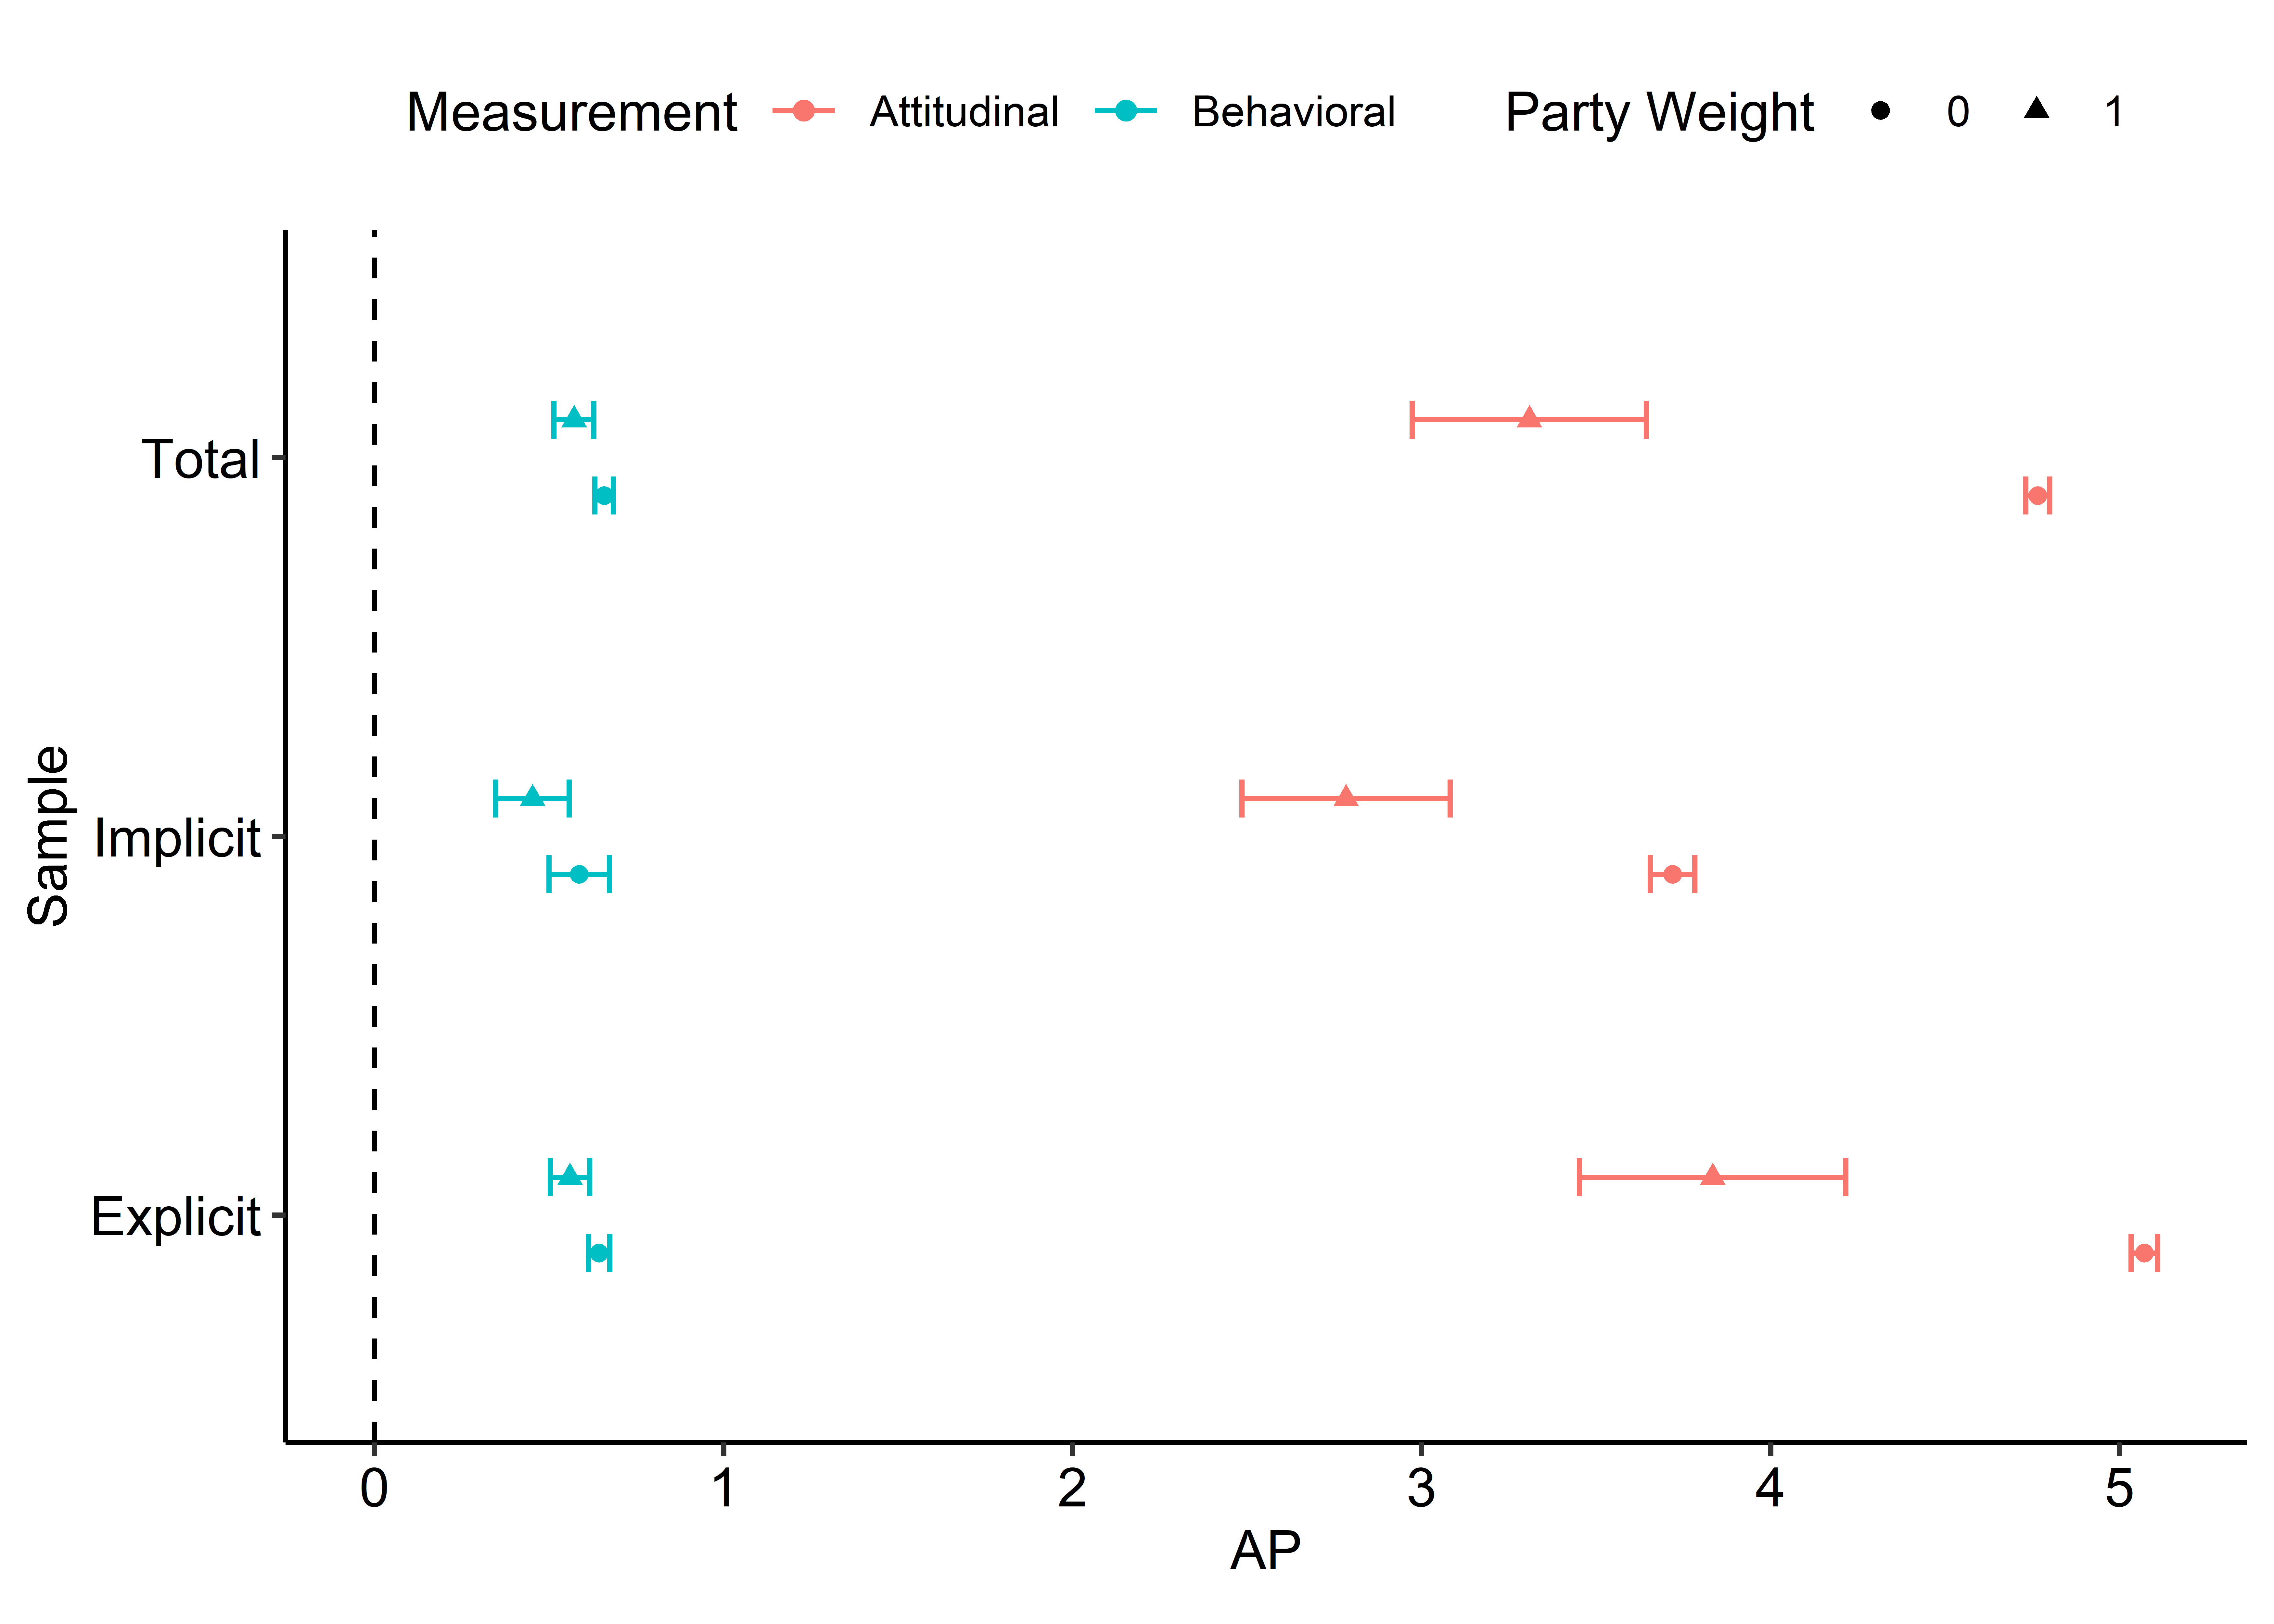

In [ ]:

toplot <- bind_rows(
  pooled_ap_cj,
  pooled_ap_thermo
)

ggplot(
  toplot,
  aes(
    x = ap,
    y = der_partisan_type,
    shape = factor(weighted),
    color = measurement
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = ifelse(toplot$weighted == 1, 0.1, -0.1))
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = ifelse(toplot$weighted == 1, 0.1, -0.1)),
    width = 0.1
  ) +
  labs(
    y = "Sample",
    x = "AP",
    shape = "Party Weight",
    color = "Measurement"
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618)


… to be continued with Wagners measures

## Spread of like-dislike scores

\[I\]t is the average absolute party like-dislike difference relative to each respondent’s average party like-dislike score

$$
\text{Spread}_i = \sqrt{ \frac{ \sum_{p=1}^{P} ( \text{like}_{ip} - \overline{\text{like}}_{i})^2 } {n_p}}
$$

In [ ]:

# Calculate Spread per respondent
api_spread_individual <- thermo_long |>
  group_by(meta_pid, der_partisan_type) |>
  summarise(
    # Wagner's Spread is the standard deviation of all party evaluations for individual i
    spread_score = sd(thermo_score, na.rm = TRUE),
    n_parties = n(),
    .groups = "drop"
  ) |>
  # Filter for respondents who rated at least 2 parties
  filter(n_parties >= 2, !is.na(spread_score))

# Aggregate by Partisan Type
pooled_ap_spread <- api_spread_individual |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

# Aggregate for Total
total_ap_spread <- api_spread_individual |>
  filter(!is.na(der_partisan_type)) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(der_partisan_type = "Total")

# Combine and format for toplot
pooled_ap_spread <- bind_rows(pooled_ap_spread, total_ap_spread) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Spread",
    outcome = "Thermo Score",
    weighted = 0
  ) |>
  select(
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_spread)


The Weighted Affective Polarization (WAP) equation for parties $j$ and voter $i$ is:

$$
\text{Spread}_i = \sqrt{ \sum_{p=1}^{P} v_p ( \text{like}_{ip} - \overline{\text{like}}_{i})^2 }
$$

$v_p$ is the vote share of each party, measured as a proportion with a range from 0 to 1. The mean affect should itself be weighted by party size and is calculated as:

$$
\overline{like}_i = \sum_{p=1}^{p} ( v_p * \text{like}_{ip})
$$

In [ ]:

# 1. Attach party vote shares (v_p) to every evaluation
thermo_weighted_ind <- thermo_long |>
  left_join(
    votes_per_party |>
      select(meta_country, der_vote_combined_name, v_p = der_anchor_vote_share),
    by = c("meta_country", "thermo_party" = "der_vote_combined_name")
  ) |>
  filter(!is.na(v_p), !is.na(thermo_score))

# 2. Calculate Individual Weighted Spread using your formulas
api_spread_weighted_ind <- thermo_weighted_ind |>
  group_by(meta_pid, der_partisan_type, meta_country) |>
  summarise(
    # Formula: Mean like = sum(v_p * like)
    # Note: sum(v_p) might be < 1 if not all parties were rated, so we normalize
    w_sum_v = sum(v_p),
    weighted_mean = sum(v_p * thermo_score) / w_sum_v,

    # Formula: Spread = sqrt( sum( v_p * (like - mean)^2 ) )
    # Again, normalizing by sum(v_p) ensures the weighted variance is scale-correct
    spread_score = sqrt(sum(v_p * (thermo_score - weighted_mean)^2) / w_sum_v),
    n_parties = n(),
    .groups = "drop"
  ) |>
  filter(n_parties >= 2)

# 3. Aggregate for the European Level (Country-Averaging)
# We aggregate to country first to ensure each country contributes equally
ap_country_spread_w <- api_spread_weighted_ind |>
  group_by(meta_country, der_partisan_type) |>
  summarise(ap_country = mean(spread_score), .groups = "drop")

# 4. Final European Scores
ap_europe_spread_weighted <- ap_country_spread_w |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

# 5. Total Weighted Score (including everyone)
total_ap_spread_weighted <- ap_country_spread_w |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(ap_country_total = mean(ap_country), .groups = "drop") |>
  summarise(
    ap = mean(ap_country_total),
    se = sd(ap_country_total) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se
  ) |>
  mutate(der_partisan_type = "Total")

# Combine for toplot
pooled_ap_spread_weighted <- bind_rows(
  ap_europe_spread_weighted,
  total_ap_spread_weighted
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Spread",
    outcome = "Thermo Score",
    weighted = 1
  ) |>
  select(-se)

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_spread_weighted)


## Mean distance from the most-liked party

This ‘mean-distance’ measure captures how much lower on average an individual’s affect for other parties is. Hence, this measure assumes positive identification with one party as the key aspect of affect patterns.

$$
\text{Distance}_i = \sqrt{ \frac{ \sum_{p=1}^{P} (\text{like}_{ip} - \text{like}_{max,i})^2 }{n_p} }
$$

This time, $n$ is the number of parties without the most-liked party. $\text{like}_{max}$ is the score assigned to the most-liked party.

In [ ]:

# 1. Calculate Individual Level Mean Distance
distance_individual <- thermo_long |>
  group_by(meta_pid, der_partisan_type, meta_country) |>
  mutate(
    # Identify the maximum score for this individual
    like_max = max(thermo_score, na.rm = TRUE)
  ) |>
  # Exclude the party/parties that have the maximum score
  # If multiple parties are tied for max, Wagner typically excludes all of them
  # from the summation to focus on the 'distance' to the rest.
  filter(thermo_score < like_max) |>
  summarise(
    # n_p is the number of parties remaining after excluding the max
    n_p = n(),
    # Formula: sqrt( sum( (like - like_max)^2 ) / n_p )
    distance_score = sqrt(sum((thermo_score - like_max)^2) / n_p),
    .groups = "drop"
  ) |>
  # Ensure we have at least one party to compare against the max
  filter(n_p >= 1, !is.na(distance_score))

# 2. Aggregate by Partisan Type (Pooled)
pooled_ap_distance <- distance_individual |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

# 3. Aggregate for Total (Pooled)
total_ap_distance <- distance_individual |>
  filter(!is.na(der_partisan_type)) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(der_partisan_type = "Total")

# 4. Combine and format for toplot
pooled_ap_distance <- bind_rows(pooled_ap_distance, total_ap_distance) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Distance",
    outcome = "Thermo Score",
    weighted = 0
  ) |>
  select(
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_distance)


Again, we can also calculate a weighted version of this measure. This would then take into account that it should matter more if an individual strongly dislikes large parties rather than a small, insignificant competitor.

$$
\text{Distance}_i = \sqrt{{ \sum_{p=1}^{P} v_p (\text{like}_{ip} - \text{like}_{max,i})^2 } }
$$

In [ ]:

# 1. Prepare data with weights and identify individual max affect
thermo_dist_weighted <- thermo_long |>
  left_join(
    votes_per_party |>
      select(meta_country, der_vote_combined_name, v_p = der_anchor_vote_share),
    by = c("meta_country", "thermo_party" = "der_vote_combined_name")
  ) |>
  filter(!is.na(v_p), !is.na(thermo_score)) |>
  group_by(meta_pid) |>
  mutate(like_max = max(thermo_score, na.rm = TRUE)) |>
  # Focus only on the distance for parties that are NOT the most-liked
  filter(thermo_score < like_max) |>
  ungroup()

# 2. Individual Level Weighted Distance
api_distance_weighted_ind <- thermo_dist_weighted |>
  group_by(meta_pid, der_partisan_type, meta_country) |>
  summarise(
    # sum of weights for the non-max parties
    w_sum_v = sum(v_p),
    # Weighted Distance formula
    distance_score = sqrt(sum(v_p * (thermo_score - like_max)^2) / w_sum_v),
    n_p = n(),
    .groups = "drop"
  ) |>
  filter(n_p >= 1)

# 3. Aggregate to Country Level (to ensure equal country weight)
ap_country_distance_w <- api_distance_weighted_ind |>
  group_by(meta_country, der_partisan_type) |>
  summarise(ap_country = mean(distance_score), .groups = "drop")

# 4. European Aggregation by Partisan Type
ap_europe_distance_weighted <- ap_country_distance_w |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

# 5. Total Weighted European Score
total_ap_distance_weighted <- ap_country_distance_w |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(ap_country_total = mean(ap_country), .groups = "drop") |>
  summarise(
    ap = mean(ap_country_total),
    se = sd(ap_country_total) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se
  ) |>
  mutate(der_partisan_type = "Total")

# 6. Combine for toplot
pooled_ap_distance_weighted <- bind_rows(
  ap_europe_distance_weighted,
  total_ap_distance_weighted
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Distance",
    outcome = "Thermo Score",
    weighted = 1
  ) |>
  select(-se)

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_distance_weighted)


# Figure

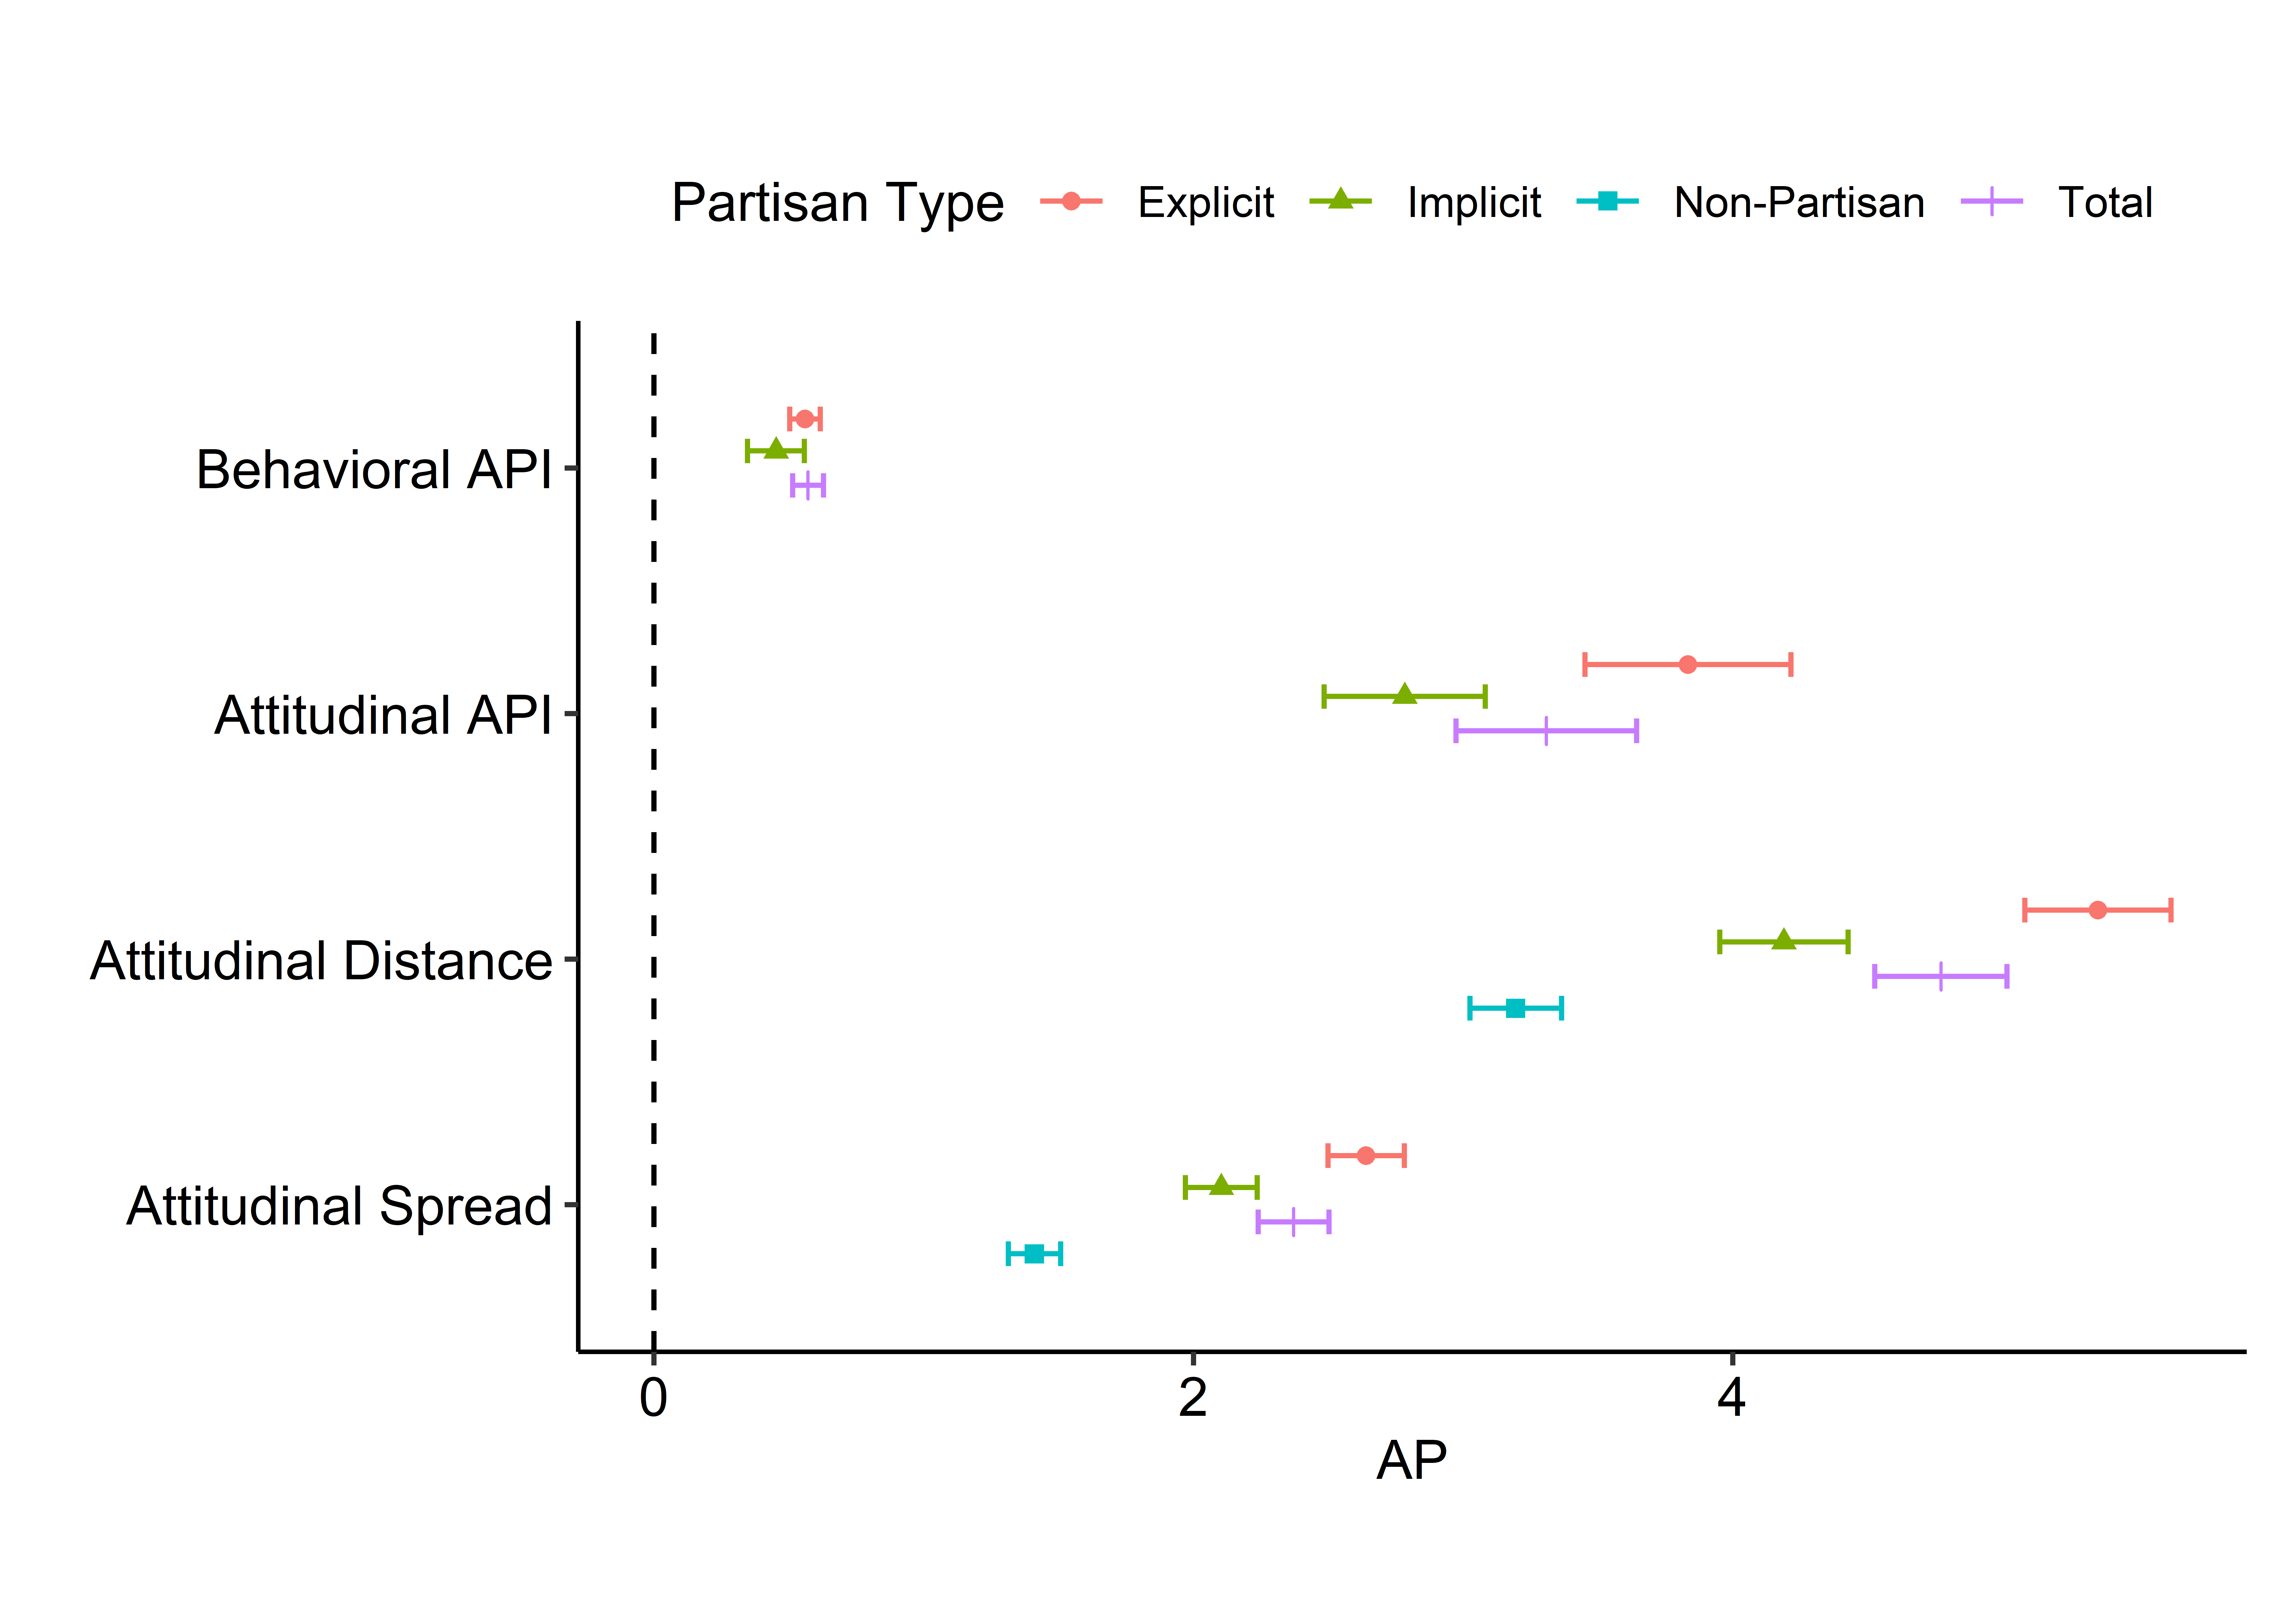

In [ ]:

toplot_eu25 <- bind_rows(
  pooled_ap_cj,
  pooled_ap_thermo
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_eu25 <- toplot_eu25 |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_eu25_2 <- toplot_eu25 |>
  filter(weighted == 1)

ggplot(
  toplot_eu25_2,
  aes(
    x = ap,
    y = y,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_eu25_2$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_eu25_2$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618)


# Splitting up Thermo and CJ

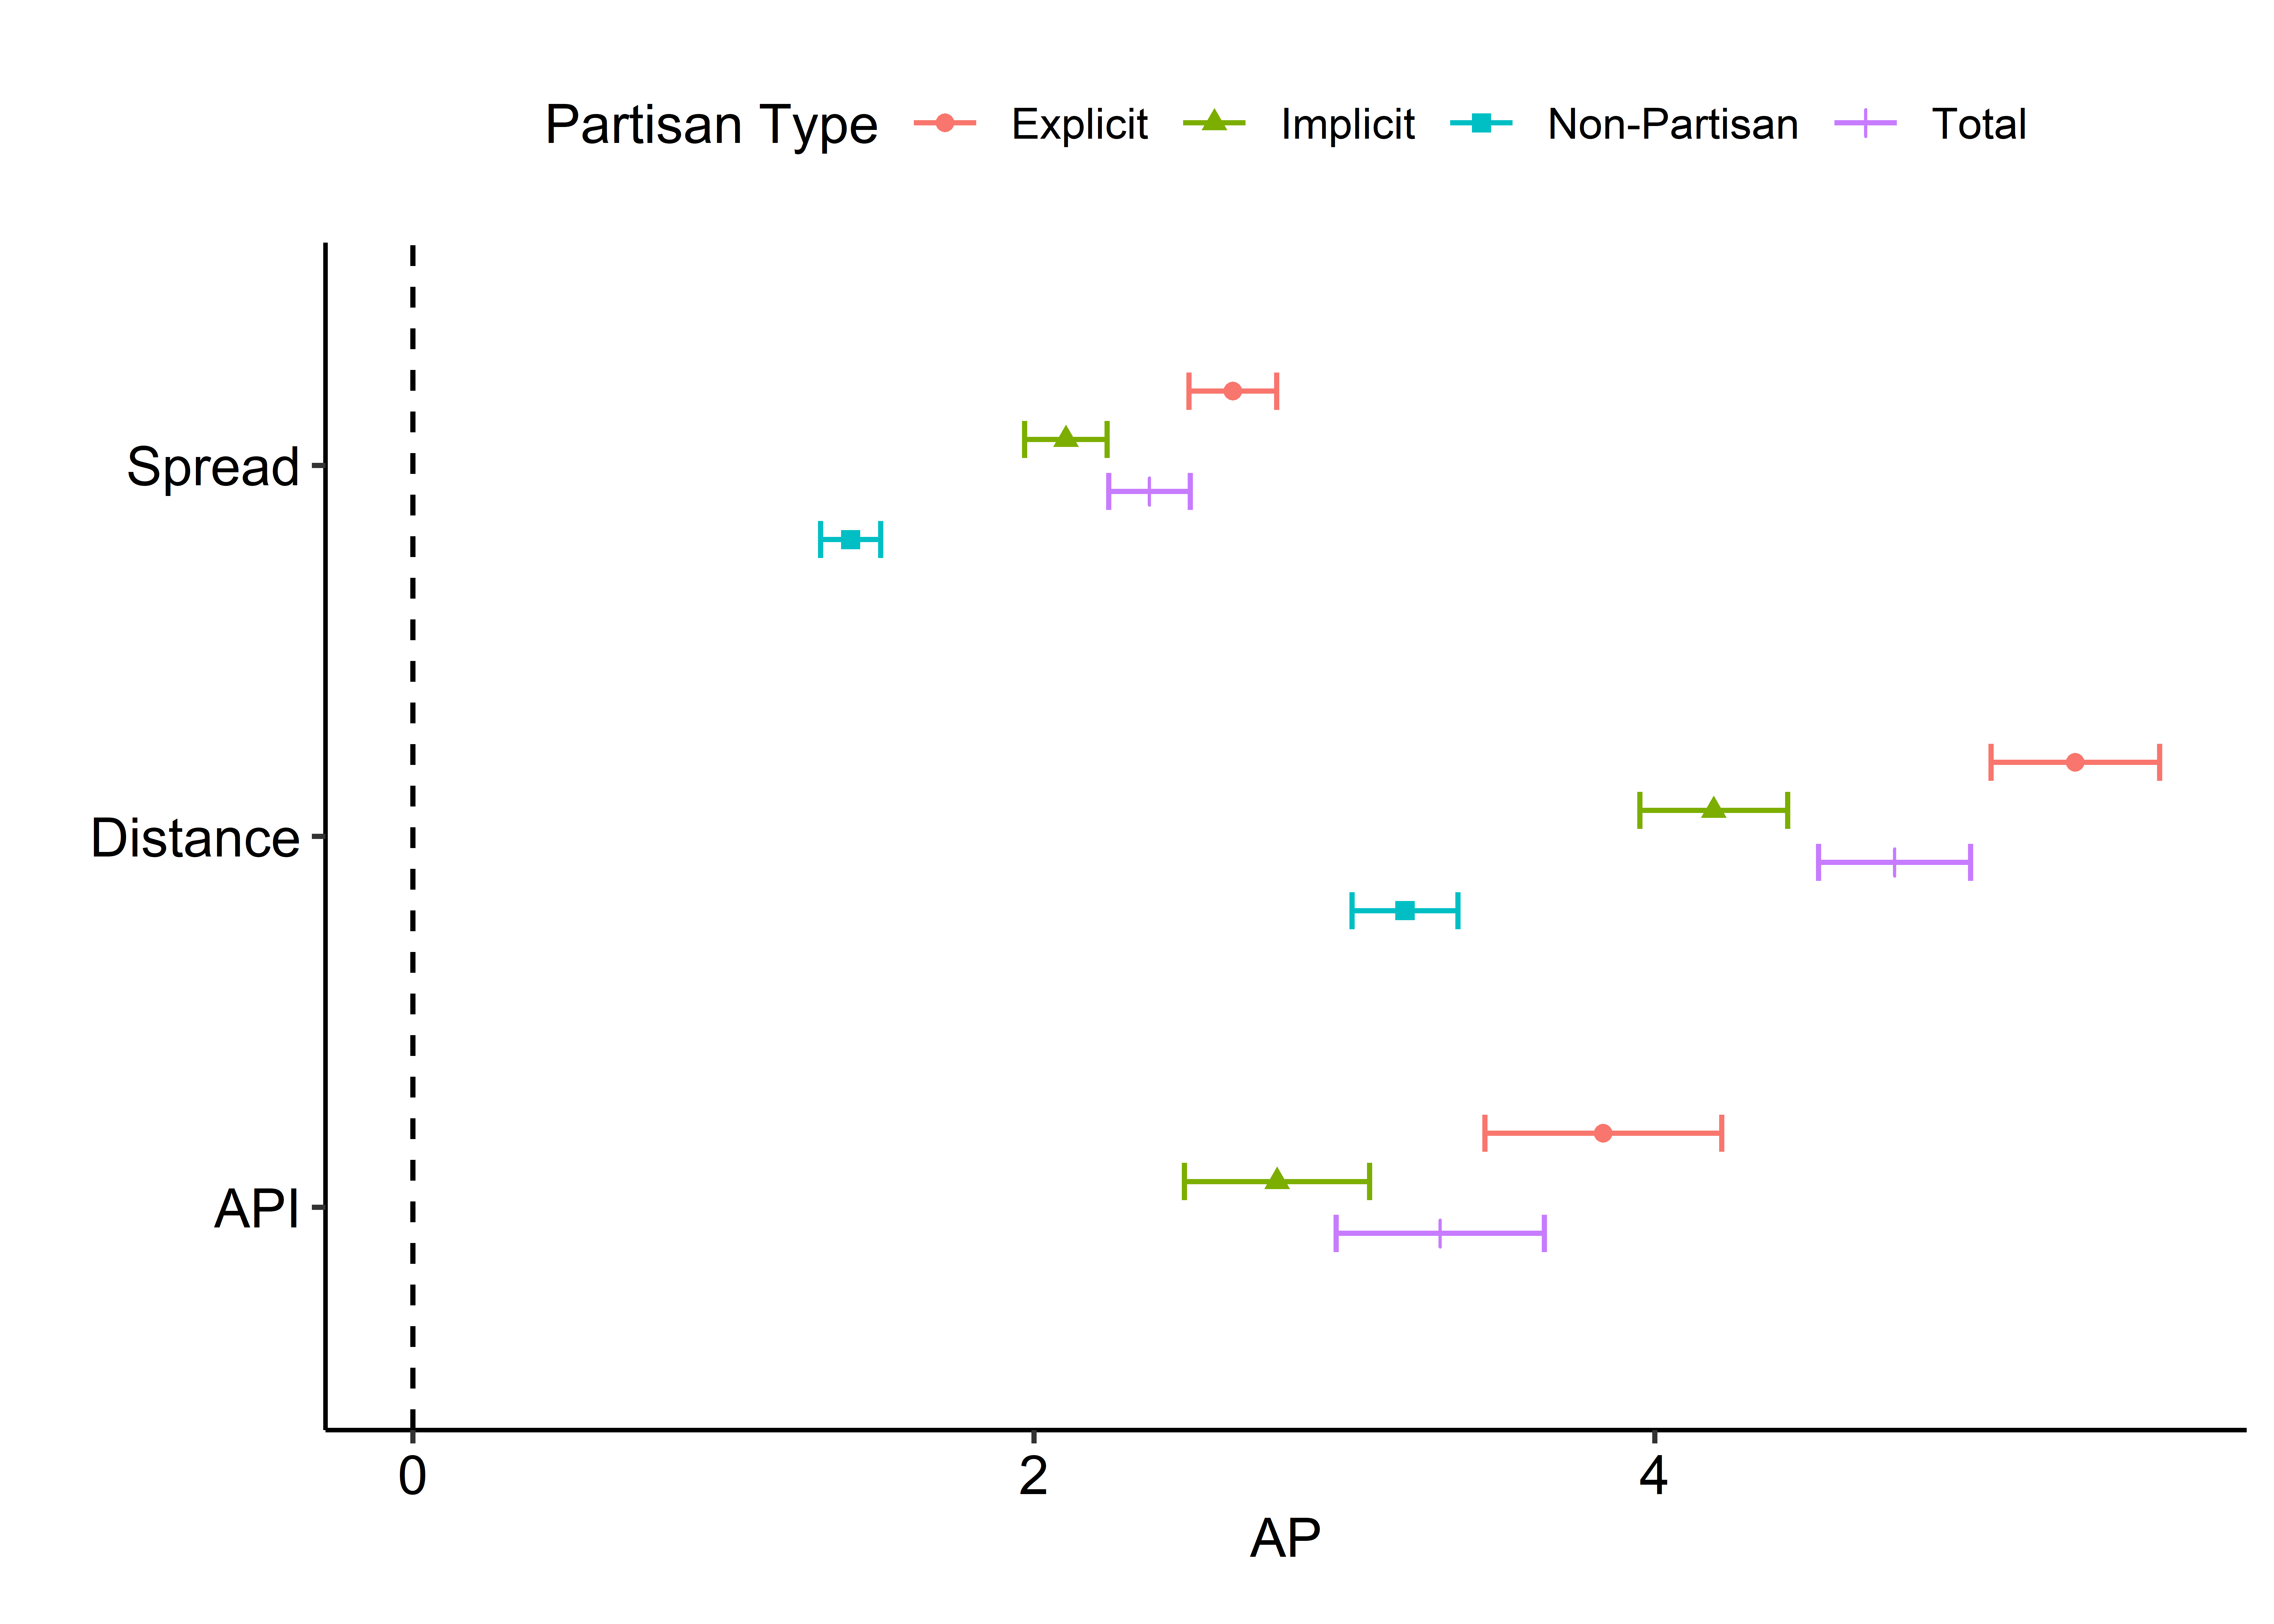

In [ ]:

toplot_eu25 <- bind_rows(
  pooled_ap_cj,
  pooled_ap_thermo
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_eu25 <- toplot_eu25 |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_eu25_3 <- toplot_eu25 |>
  filter(
    weighted == 1,
    measurement == "Attitudinal"
  )

ggplot(
  toplot_eu25_3,
  aes(
    x = ap,
    y = measure,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_eu25_3$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_eu25_3$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618)


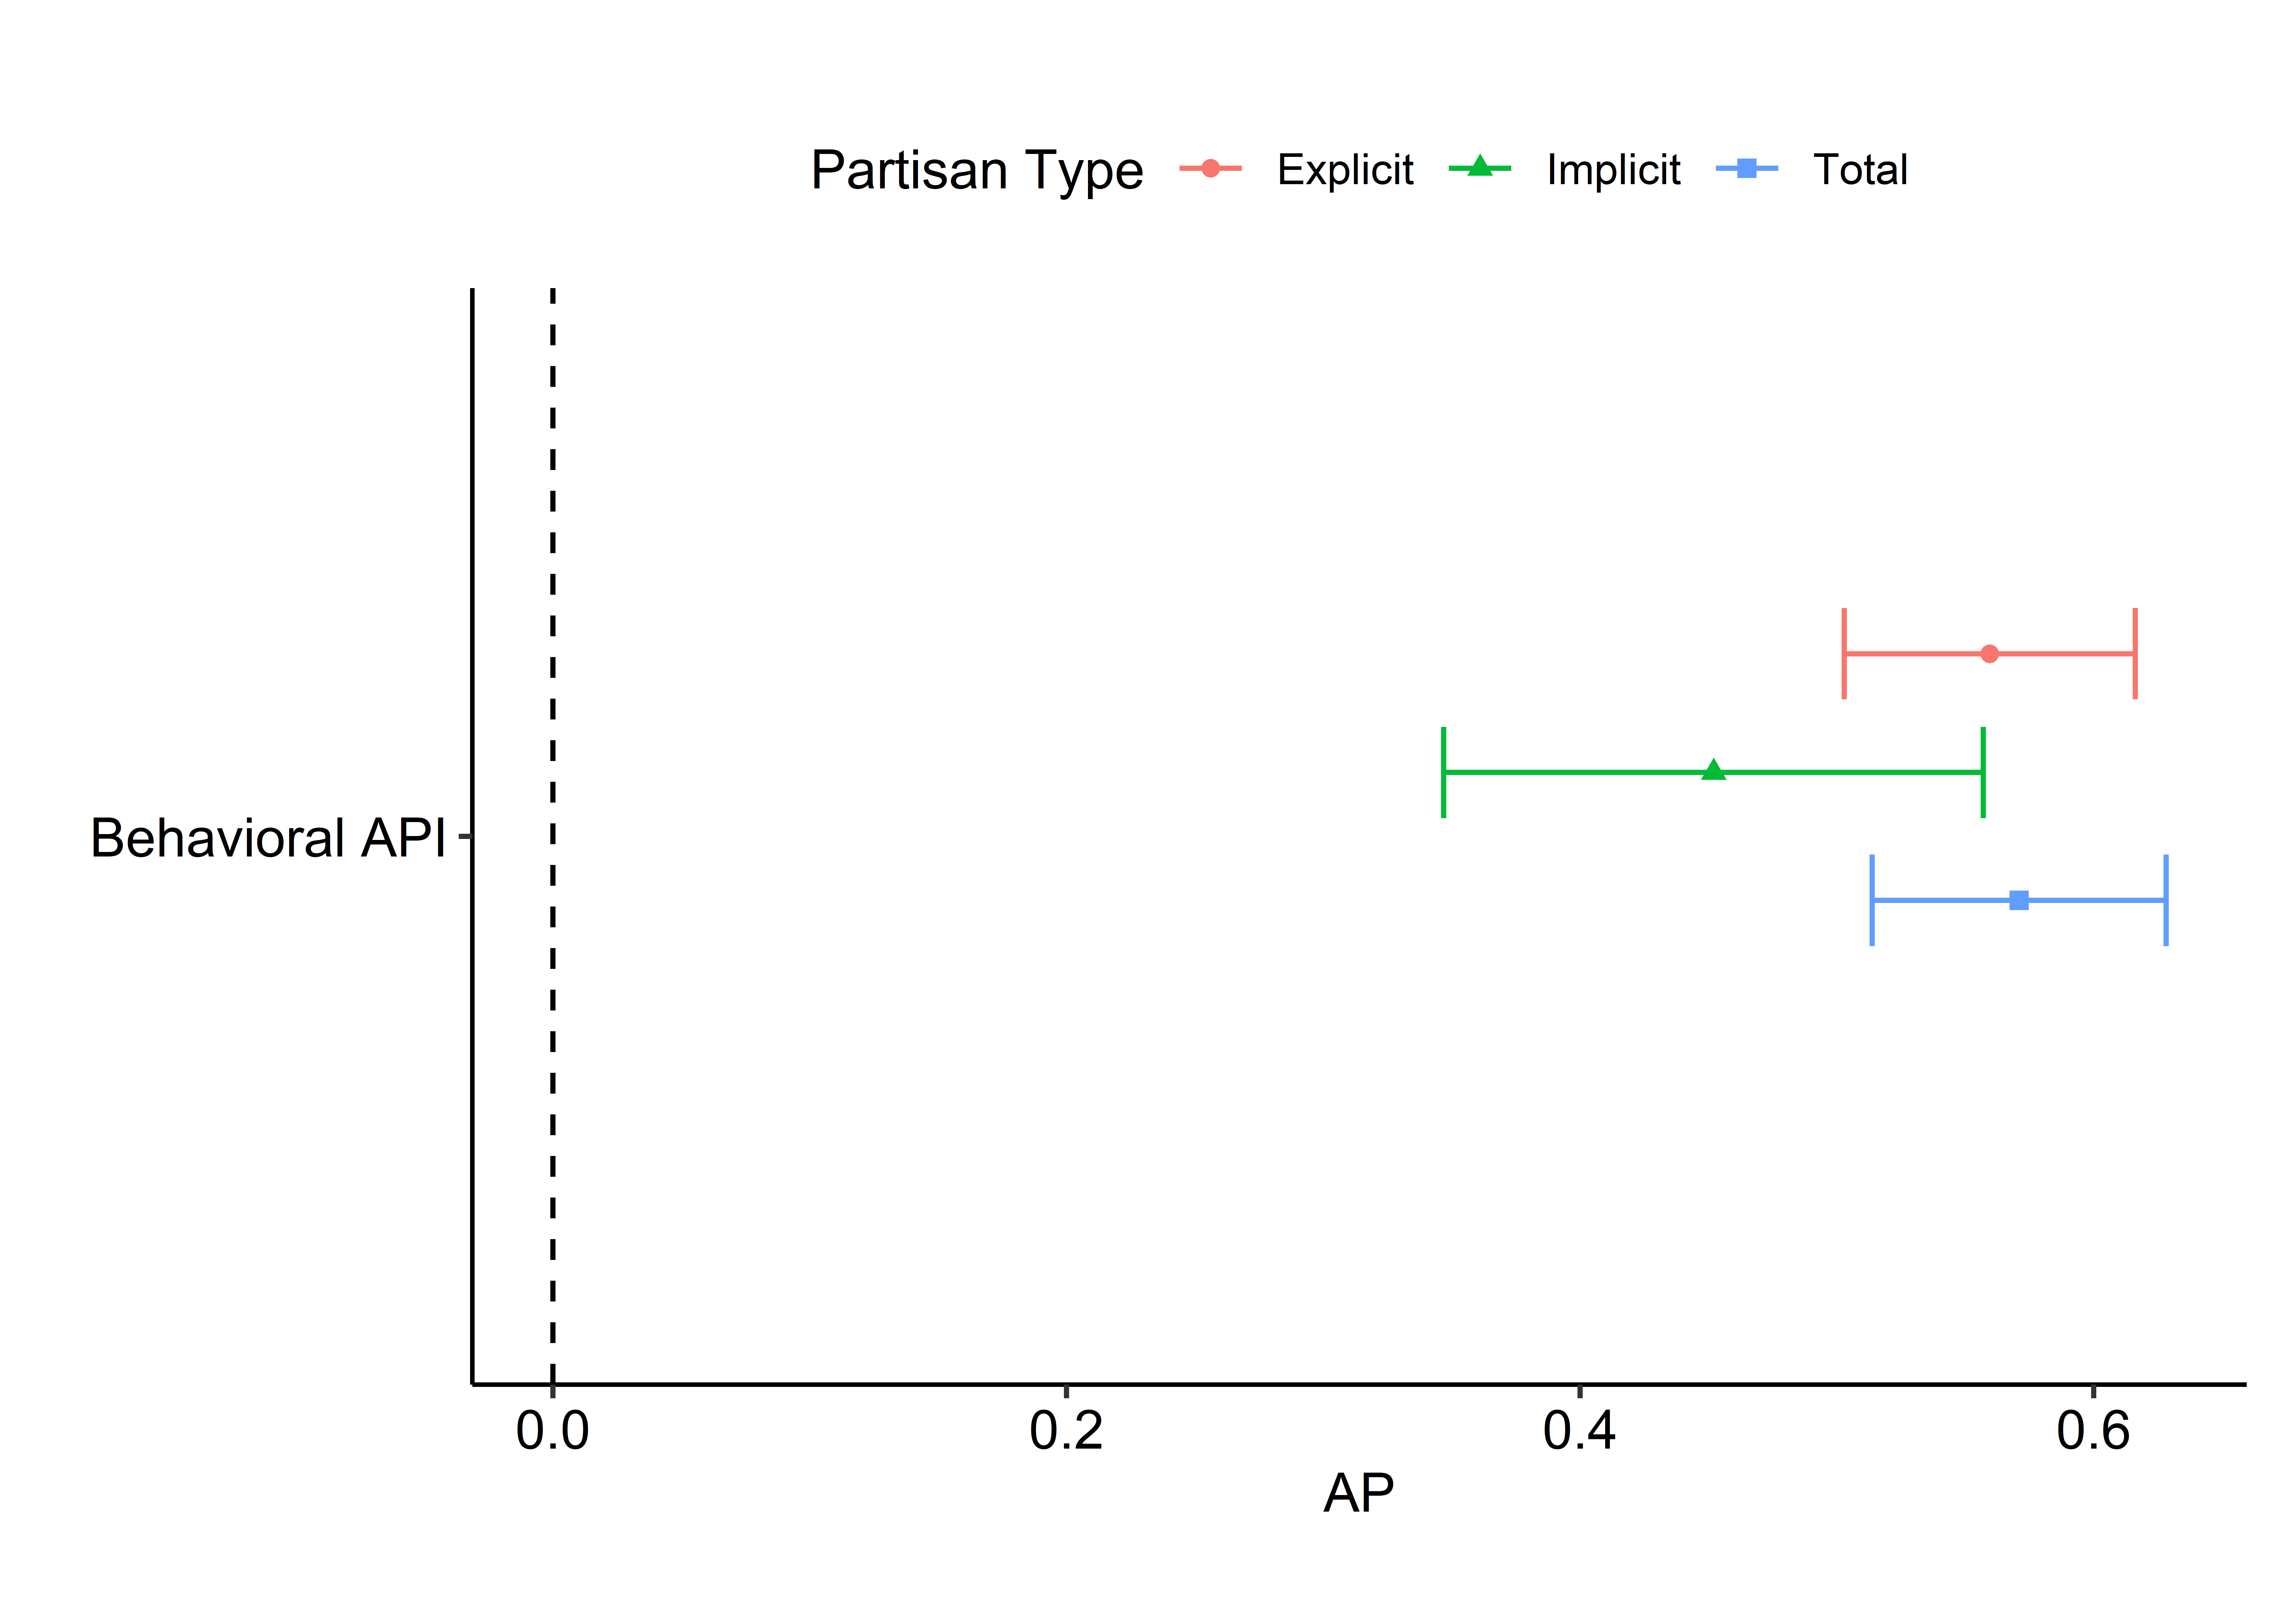

In [ ]:

toplot_eu25 <- bind_rows(
  pooled_ap_cj,
  pooled_ap_thermo
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_eu25 <- toplot_eu25 |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_eu25_4 <- toplot_eu25 |>
  filter(
    weighted == 1,
    measurement == "Behavioral"
  )

ggplot(
  toplot_eu25_4,
  aes(
    x = ap,
    y = y,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_eu25_4$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_eu25_4$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618)


# By Country

In [ ]:

# 1. Explicit / Implicit within each country -----------------------------

ap_cj_country_unw <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type)
  ) |>
  group_by(meta_country, der_partisan_type, der_partisan_relationship) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap = mean_Co - mean_Out,
    se = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit"
    )
  )


# 2. Total AP within each country ---------------------------------------

ap_cj_country_total_unw <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type)
  ) |>
  group_by(meta_country, der_partisan_relationship) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap = mean_Co - mean_Out,
    se = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    der_partisan_type = "Total"
  )


# 3. Combine and format --------------------------------------------------

ap_cj_country_unw <- bind_rows(
  ap_cj_country_unw,
  ap_cj_country_total_unw
) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high
  ) |>
  mutate(
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    weighted = 0
  )


In [ ]:

########################################
# 1. Party-level AP within country
########################################

ap_country_party_weighted <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type),
    !is.na(der_anchor_vote_share)
  ) |>
  group_by(
    meta_country,
    der_partisan_type,
    der_partisan_anchor,
    der_partisan_relationship
  ) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap_party = mean_Co - mean_Out,
    # delta-method SE for party-level difference
    se_party = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out)
  )


########################################
# 2. Weight by party vote share
########################################

ap_country_weighted <- ap_country_party_weighted |>
  left_join(
    eu25games2019 |>
      distinct(meta_country, der_partisan_anchor, der_anchor_vote_share),
    by = c("meta_country", "der_partisan_anchor")
  ) |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    # weighted AP
    ap = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),

    # approximate SE assuming independence across parties
    se = sqrt(sum((der_anchor_vote_share^2) * (se_party^2), na.rm = TRUE)),

    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    weighted = 1,
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit"
    )
  )


########################################
# 3. Total AP within country
########################################

ap_country_party_total_w <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_anchor_vote_share)
  ) |>
  group_by(
    meta_country,
    der_partisan_anchor,
    der_partisan_relationship
  ) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap_party = mean_Co - mean_Out,
    se_party = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out)
  )


ap_country_weighted_total <- ap_country_party_total_w |>
  left_join(
    eu25games2019 |>
      distinct(meta_country, der_partisan_anchor, der_anchor_vote_share),
    by = c("meta_country", "der_partisan_anchor")
  ) |>
  group_by(meta_country) |>
  summarise(
    ap = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),
    se = sqrt(sum((der_anchor_vote_share^2) * (se_party^2), na.rm = TRUE)),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total",
    weighted = 1,
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token"
  )


########################################
# 4. Final country-level tibble
########################################

ap_cj_country_weighted <- bind_rows(
  ap_country_weighted,
  ap_country_weighted_total
) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )


In [ ]:

# calculate individual level AP within country
api_individual_country <- thermo_long |>
  mutate(
    ingroup = thermo_party == der_partisan_anchor
  ) |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  summarise(
    mean_Co = mean(thermo_score[ingroup], na.rm = TRUE),
    mean_Out = mean(thermo_score[!ingroup], na.rm = TRUE),
    api = mean_Co - mean_Out,
    n_Co = sum(ingroup),
    n_Out = sum(!ingroup),
    .groups = "drop"
  ) |>
  filter(n_Co > 0, n_Out > 0)

ap_thermo_country <- api_individual_country |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(api),
    sd_ap = sd(api),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 0,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      .default = NA
    )
  )


ap_thermo_country_total <- api_individual_country |>
  group_by(meta_country) |>
  summarise(
    ap = mean(api),
    sd_ap = sd(api),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 0,
    der_partisan_type = "Total"
  )

ap_thermo_country <- bind_rows(
  ap_thermo_country,
  ap_thermo_country_total
) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )


In [ ]:

api_individual_country <- thermo_long |>
  filter(!is.na(der_partisan_type)) |>
  mutate(ingroup = thermo_party == der_partisan_anchor) |>
  group_by(meta_country, meta_pid, der_partisan_type, der_partisan_anchor) |>
  summarise(
    mean_Co = mean(thermo_score[ingroup], na.rm = TRUE),
    mean_Out = mean(thermo_score[!ingroup], na.rm = TRUE),
    api = mean_Co - mean_Out,
    .groups = "drop"
  )

api_party_country <- api_individual_country |>
  group_by(meta_country, der_partisan_type, der_partisan_anchor) |>
  summarise(
    mean_api = mean(api, na.rm = TRUE),
    sd_api = sd(api, na.rm = TRUE),
    n_api = n(),
    var_api = (sd_api^2) / n_api, # variance of party mean
    .groups = "drop"
  )

api_party_country <- api_party_country |>
  left_join(
    votes_per_party |>
      select(
        meta_country,
        der_vote_combined_name,
        der_anchor_vote_share
      ),
    by = join_by(
      meta_country,
      der_partisan_anchor == der_vote_combined_name
    )
  )

ap_thermo_country_weighted <- api_party_country |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = sum(mean_api * der_anchor_vote_share, na.rm = TRUE),
    var_ap = sum((der_anchor_vote_share^2) * var_api, na.rm = TRUE),
    se = sqrt(var_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 1,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit"
    )
  ) |>
  select(-var_ap, -se)

api_party_total_country <- api_individual_country |>
  group_by(meta_country, der_partisan_anchor) |>
  summarise(
    mean_api = mean(api, na.rm = TRUE),
    sd_api = sd(api, na.rm = TRUE),
    n_api = n(),
    var_api = (sd_api^2) / n_api,
    .groups = "drop"
  ) |>
  left_join(
    votes_per_party |>
      select(
        meta_country,
        der_vote_combined_name,
        der_anchor_vote_share
      ),
    by = join_by(
      meta_country,
      der_partisan_anchor == der_vote_combined_name
    )
  )

ap_thermo_country_weighted_total <- api_party_total_country |>
  group_by(meta_country) |>
  summarise(
    ap = sum(mean_api * der_anchor_vote_share, na.rm = TRUE),
    var_ap = sum((der_anchor_vote_share^2) * var_api, na.rm = TRUE),
    se = sqrt(var_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 1,
    der_partisan_type = "Total"
  ) |>
  select(-var_ap, -se)

ap_thermo_country_weighted <- bind_rows(
  ap_thermo_country_weighted,
  ap_thermo_country_weighted_total
) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )


In [ ]:

api_spread_individual_country <- thermo_long |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  summarise(
    # Wagner's Spread: SD of all party ratings for respondent i
    spread_score = sd(thermo_score, na.rm = TRUE),
    n_parties = n(),
    .groups = "drop"
  ) |>
  filter(n_parties >= 2, !is.na(spread_score))


ap_spread_country <- api_spread_individual_country |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

ap_spread_country_total <- api_spread_individual_country |>
  # filter so total means total partisans
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total"
  )

ap_spread_country <- bind_rows(
  ap_spread_country,
  ap_spread_country_total
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Spread",
    outcome = "Thermo Score",
    weighted = 0
  ) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )


In [ ]:
thermo_weighted_ind <- thermo_long |>
  left_join(
    votes_per_party |>
      select(meta_country, der_vote_combined_name, v_p = der_anchor_vote_share),
    by = c("meta_country", "thermo_party" = "der_vote_combined_name")
  ) |>
  filter(!is.na(v_p), !is.na(thermo_score))

api_spread_weighted_ind <- thermo_weighted_ind |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  summarise(
    w_sum_v = sum(v_p),
    weighted_mean = sum(v_p * thermo_score) / w_sum_v,
    spread_score = sqrt(sum(v_p * (thermo_score - weighted_mean)^2) / w_sum_v),
    n_parties = n(),
    .groups = "drop"
  ) |>
  filter(n_parties >= 2, !is.na(spread_score))

ap_spread_country_weighted <- api_spread_weighted_ind |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_spread_country_weighted_total <- api_spread_weighted_ind |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total"
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_spread_country_weighted <- bind_rows(
  ap_spread_country_weighted,
  ap_spread_country_weighted_total
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Spread",
    outcome = "Thermo Score",
    weighted = 1
  ) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )


In [ ]:

distance_individual_country <- thermo_long |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  mutate(
    like_max = max(thermo_score, na.rm = TRUE)
  ) |>
  filter(thermo_score < like_max) |>
  summarise(
    n_p = n(),
    distance_score = sqrt(sum((thermo_score - like_max)^2) / n_p),
    .groups = "drop"
  ) |>
  filter(n_p >= 1, !is.na(distance_score))

ap_distance_country <- distance_individual_country |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_distance_country_total <- distance_individual_country |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total"
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_distance_country <- bind_rows(
  ap_distance_country,
  ap_distance_country_total
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Distance",
    outcome = "Thermo Score",
    weighted = 0
  ) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )


In [ ]:

thermo_dist_weighted <- thermo_long |>
  left_join(
    votes_per_party |>
      select(meta_country, der_vote_combined_name, v_p = der_anchor_vote_share),
    by = c("meta_country", "thermo_party" = "der_vote_combined_name")
  ) |>
  filter(!is.na(v_p), !is.na(thermo_score)) |>
  group_by(meta_country, meta_pid) |>
  mutate(
    like_max = max(thermo_score, na.rm = TRUE)
  ) |>
  filter(thermo_score < like_max) |>
  ungroup()

api_distance_weighted_ind <- thermo_dist_weighted |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  summarise(
    w_sum_v = sum(v_p),
    distance_score = sqrt(sum(v_p * (thermo_score - like_max)^2) / w_sum_v),
    n_p = n(),
    .groups = "drop"
  ) |>
  filter(n_p >= 1, !is.na(distance_score))

ap_distance_country_weighted <- api_distance_weighted_ind |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_distance_country_weighted_total <- api_distance_weighted_ind |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total"
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_distance_country_weighted <- bind_rows(
  ap_distance_country_weighted,
  ap_distance_country_weighted_total
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Distance",
    outcome = "Thermo Score",
    weighted = 1
  ) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )


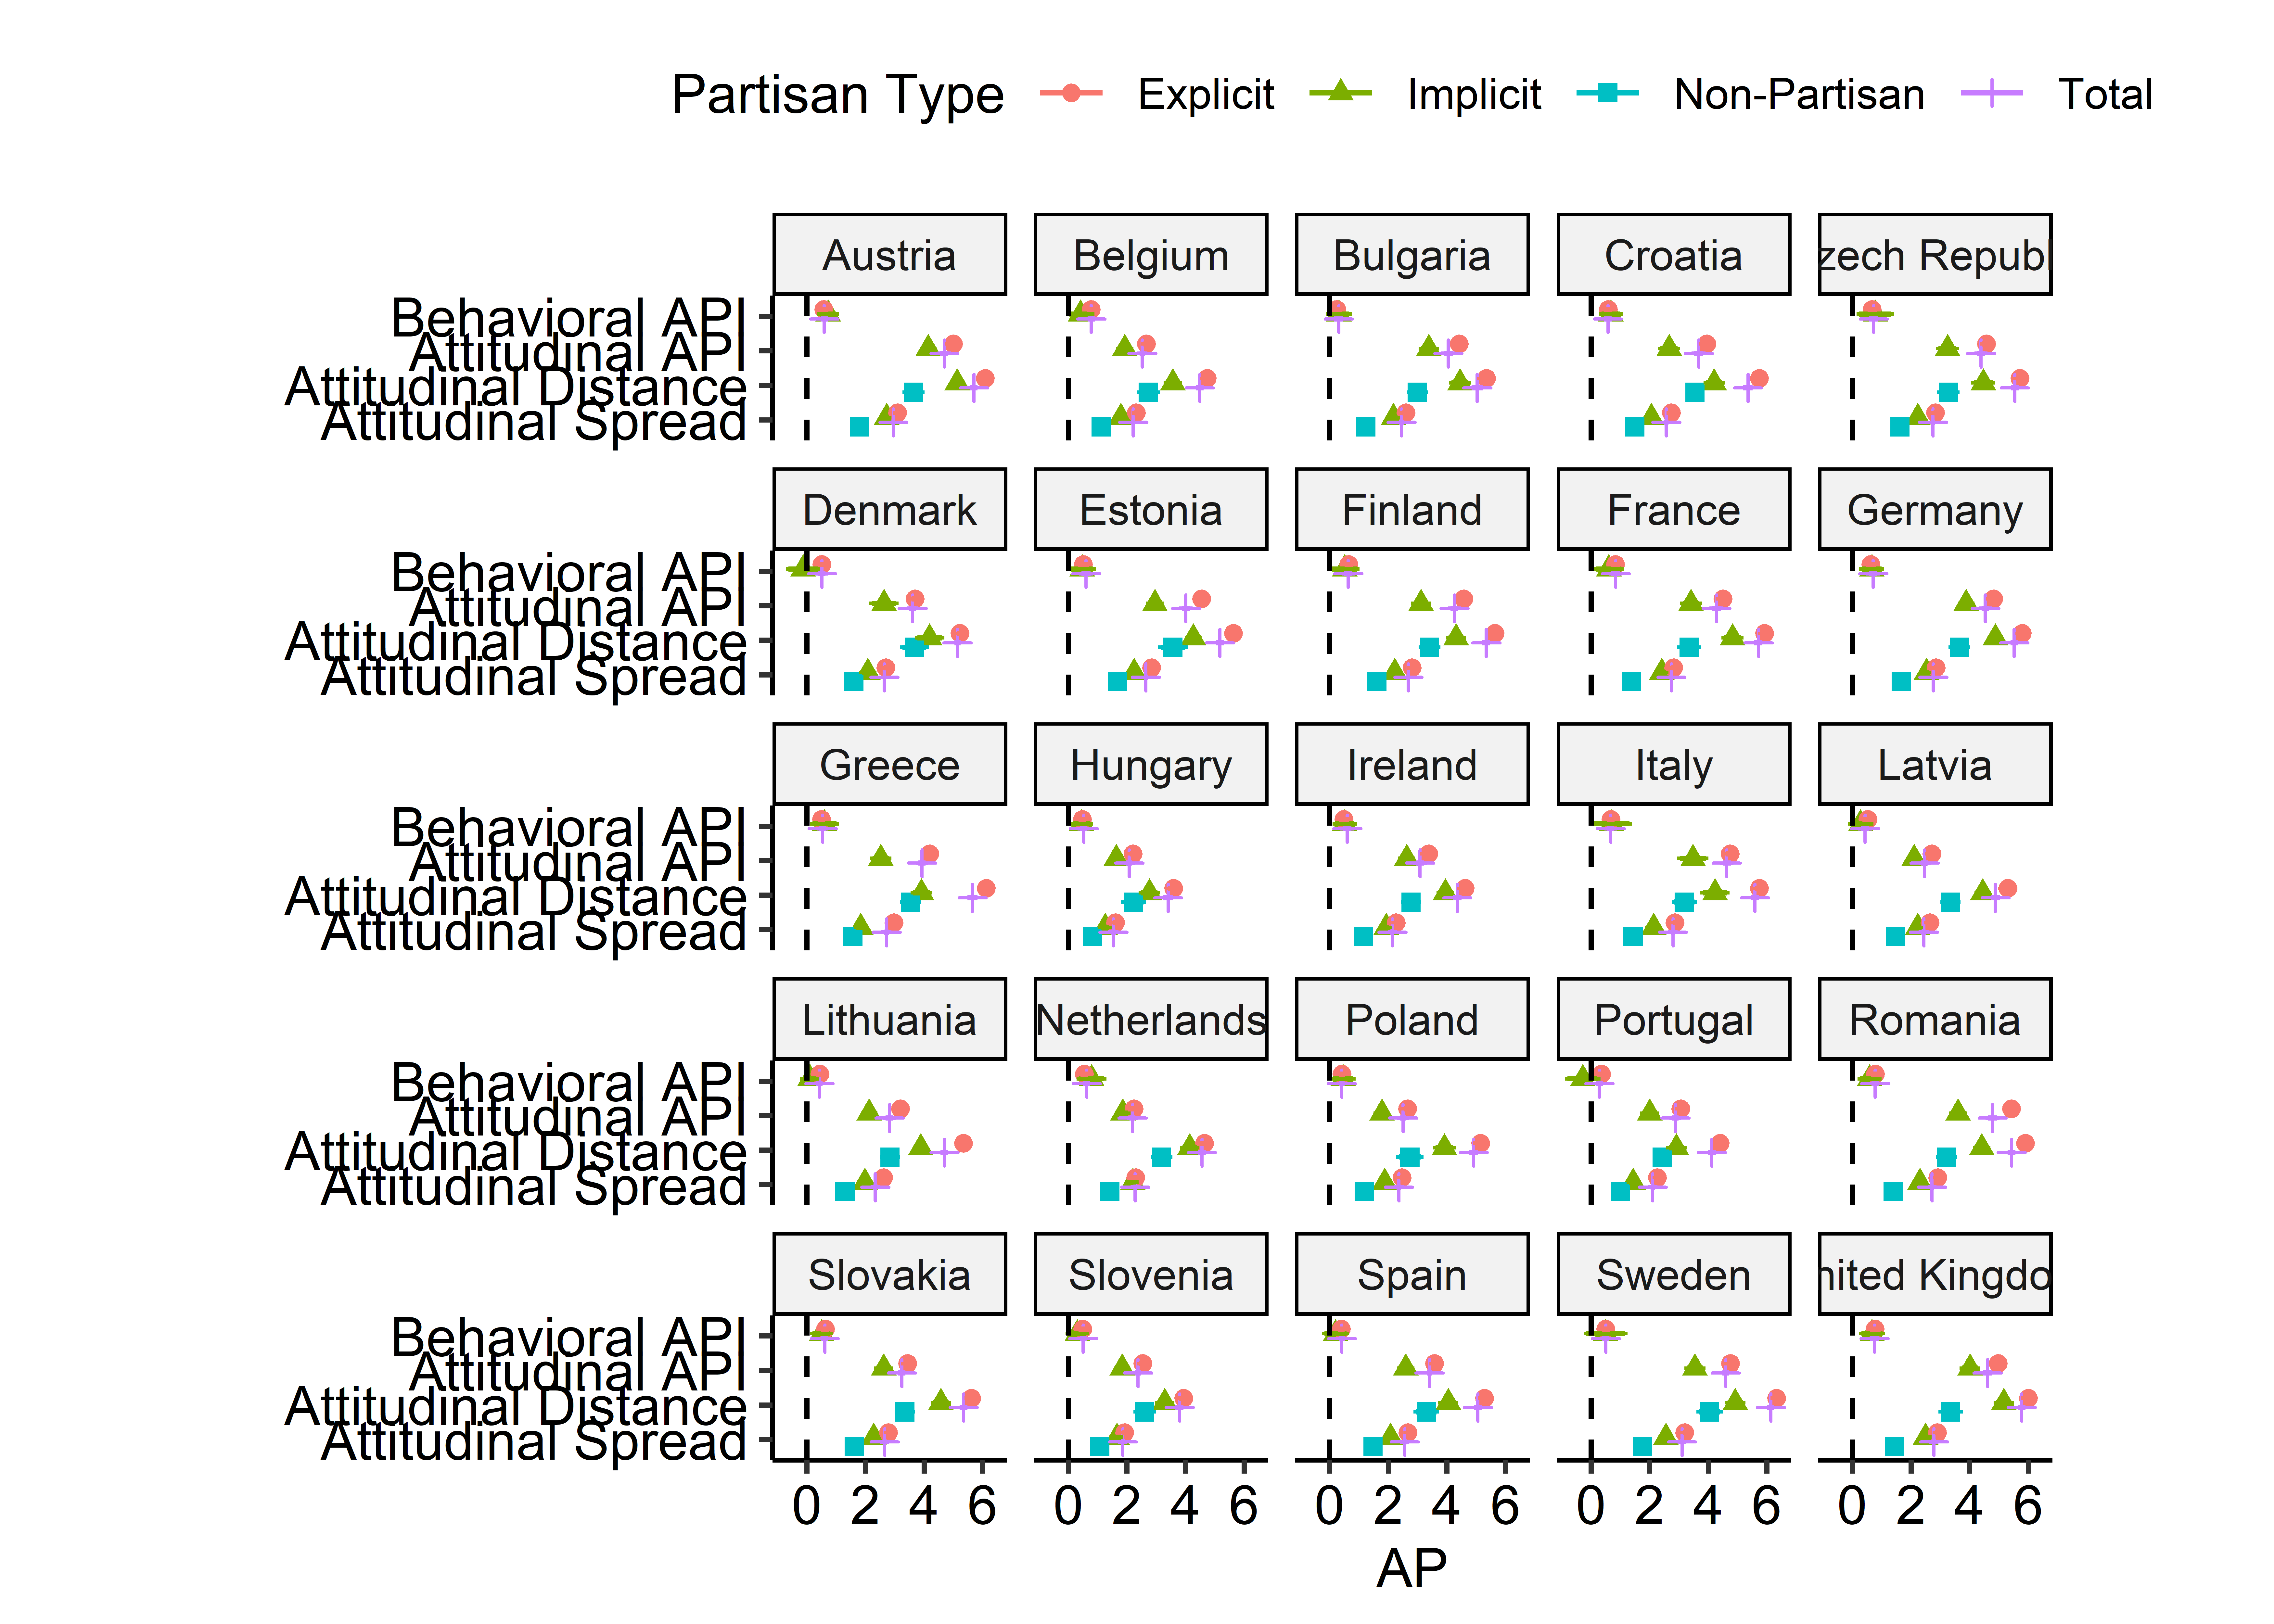

In [ ]:

toplot_country <- bind_rows(
  ap_cj_country_unw,
  ap_cj_country_weighted,
  ap_thermo_country,
  ap_thermo_country_weighted,
  ap_spread_country,
  ap_spread_country_weighted,
  ap_distance_country,
  ap_distance_country_weighted
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_country <- toplot_country |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_country2 <- toplot_country |>
  filter(weighted == 1)

ggplot(
  toplot_country2,
  aes(
    x = ap,
    y = y,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_country2$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_country2$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618) +
  facet_wrap(~meta_country)


In [ ]:

toplot_country <- bind_rows(
  ap_cj_country_unw,
  ap_cj_country_weighted,
  ap_thermo_country,
  ap_thermo_country_weighted,
  ap_spread_country,
  ap_spread_country_weighted,
  ap_distance_country,
  ap_distance_country_weighted
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_country <- toplot_country |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_country3 <- toplot_country |>
  filter(
    weighted == 1,
    measurement == "Attitudinal"
  )

ggplot(
  toplot_country3,
  aes(
    x = ap,
    y = measure,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_country3$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_country3$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  # theme(aspect.ratio = 1 / 1.618) +
  facet_wrap(~meta_country)


In [ ]:

toplot_country <- bind_rows(
  ap_cj_country_unw,
  ap_cj_country_weighted,
  ap_thermo_country,
  ap_thermo_country_weighted,
  ap_spread_country,
  ap_spread_country_weighted,
  ap_distance_country,
  ap_distance_country_weighted
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_country <- toplot_country |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_country3 <- toplot_country |>
  filter(
    weighted == 1,
    measurement == "Behavioral"
  )

ggplot(
  toplot_country3,
  aes(
    x = ap,
    y = measure,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_country3$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_country3$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  # theme(aspect.ratio = 1 / 1.618) +
  facet_wrap(~meta_country)


# New Figures

In [ ]:

expl_res <- toplot_eu25 |>
  mutate(meta_country = "EU25") |>
  relocate(meta_country, .before = der_partisan_type) |>
  bind_rows(toplot_country) |>
  rename(measure_id = y)

expl_res_w <- expl_res |>
  filter(weighted == 1)


In [ ]:

ggplot(
  expl_res_w,
  aes(
    x = ap,
    y = meta_country,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(position = position_nudge(y = expl_res_w$nudge_y)) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = expl_res_w$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1) +
  facet_wrap(~measure_id, scales = "free")


# Country AP rankings

This section shows country rankings of AP values by partisan type and measurement. Use the tabs below to explore each measure.

## Behavioral API

## Implicit

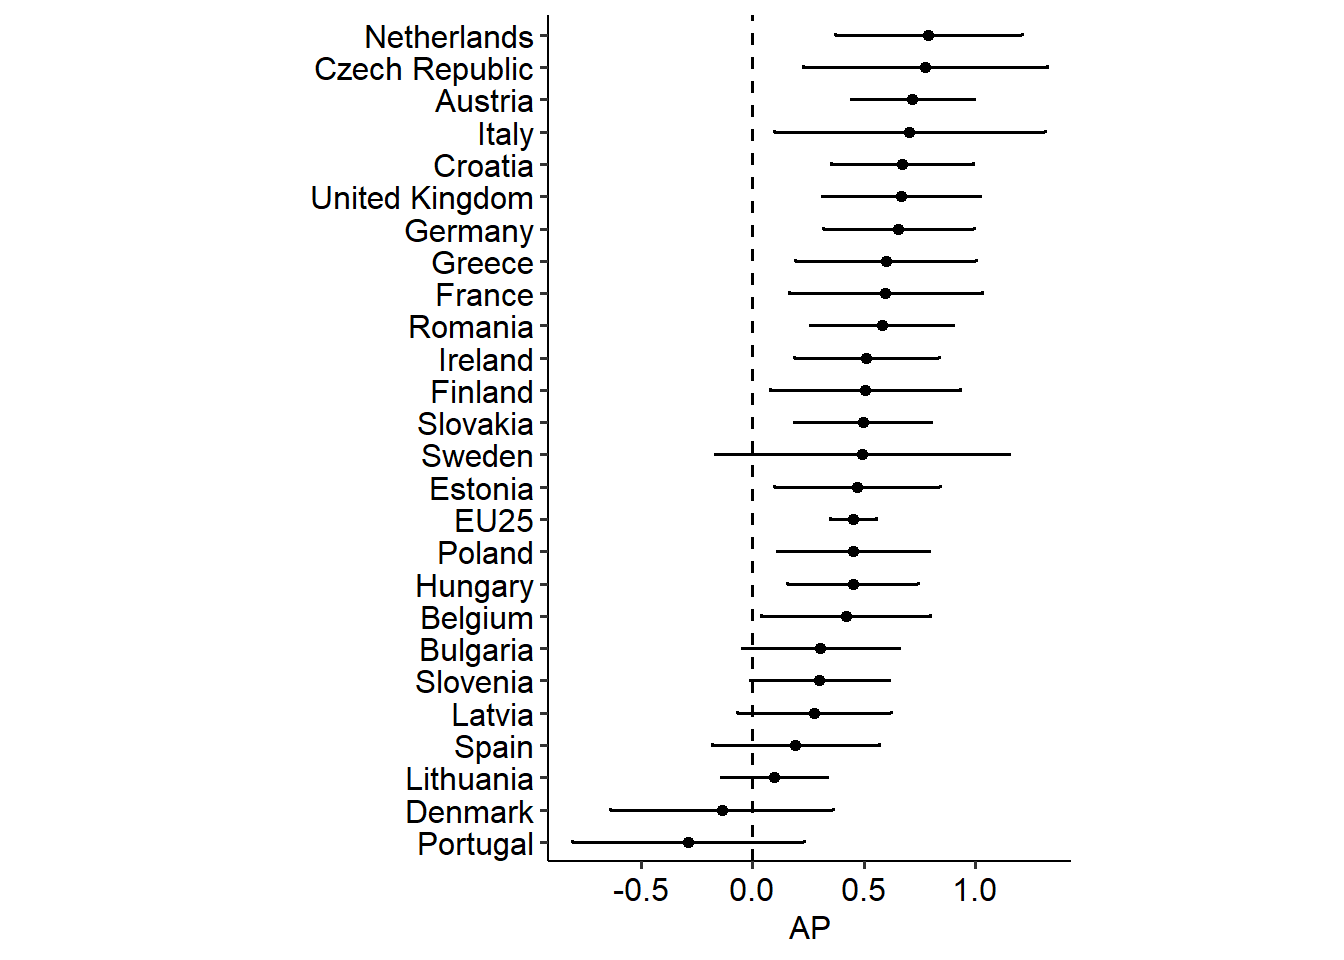

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Implicit",
    measure_id == "Behavioral API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Explicit

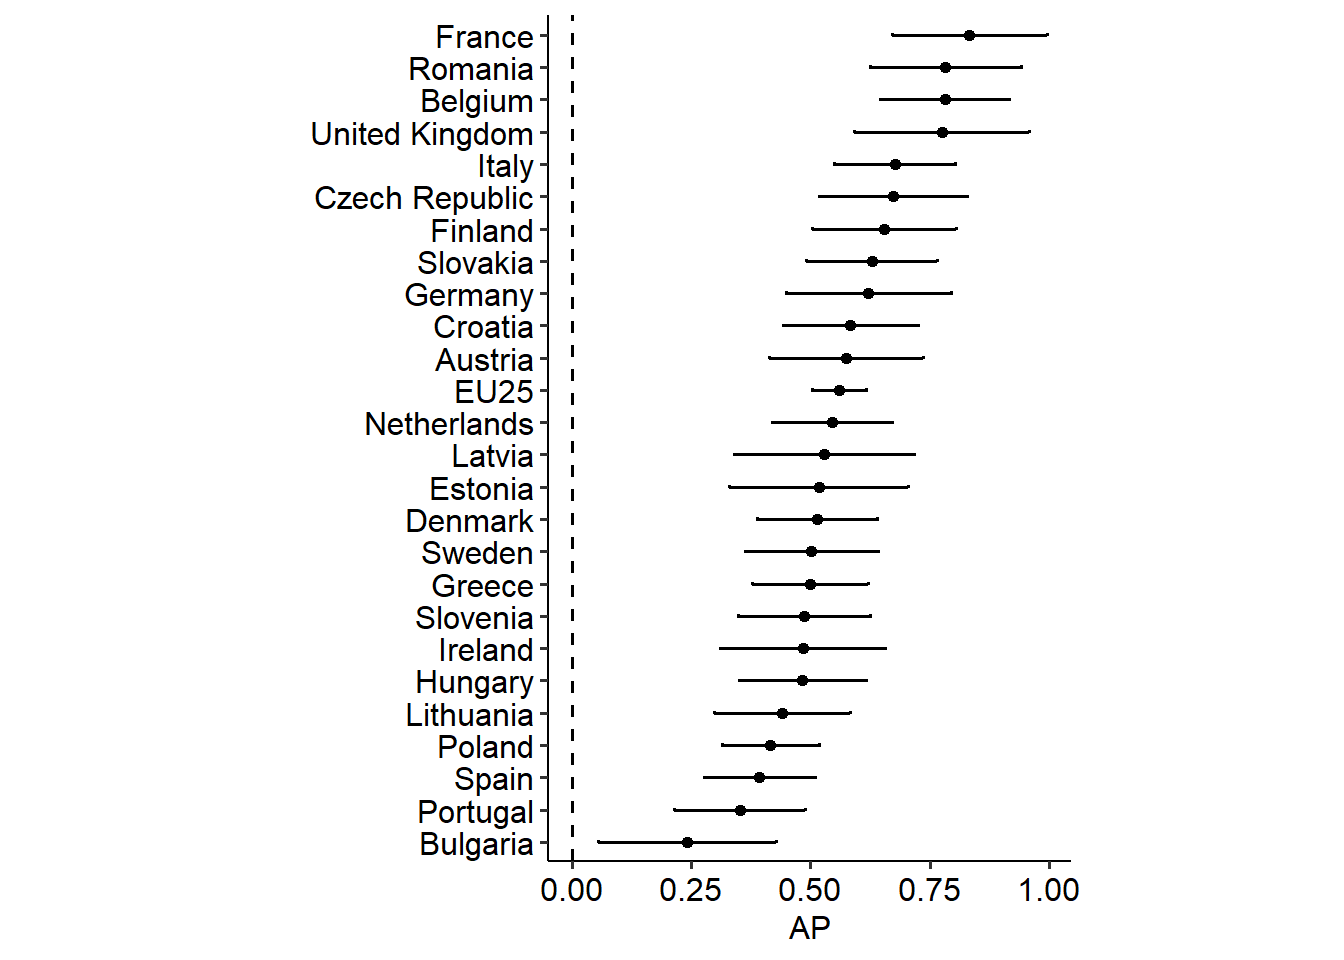

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Explicit",
    measure_id == "Behavioral API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Total

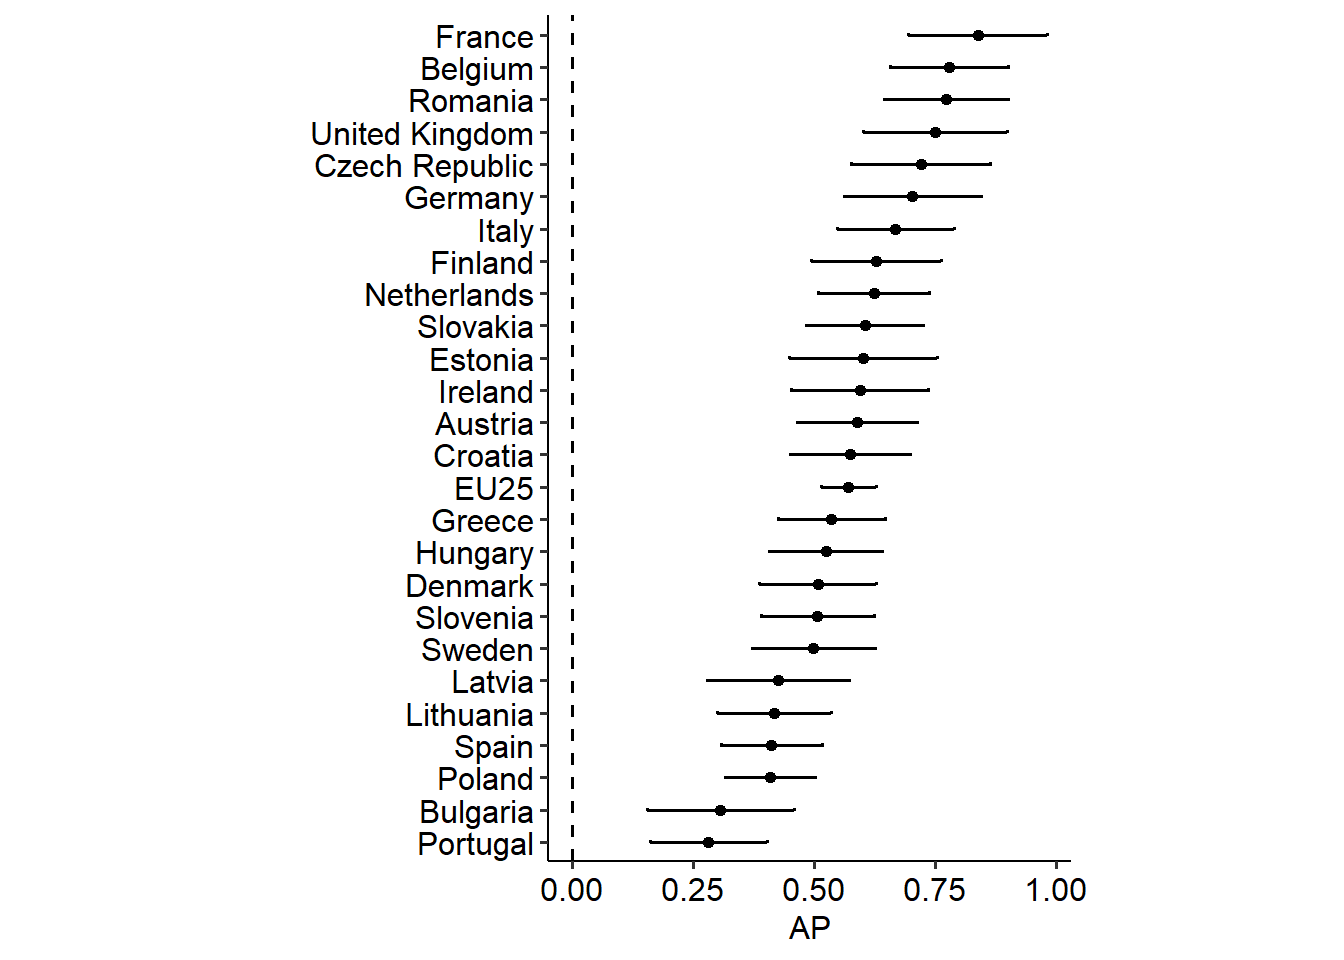

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Total",
    measure_id == "Behavioral API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Attitudinal API

## Implicit

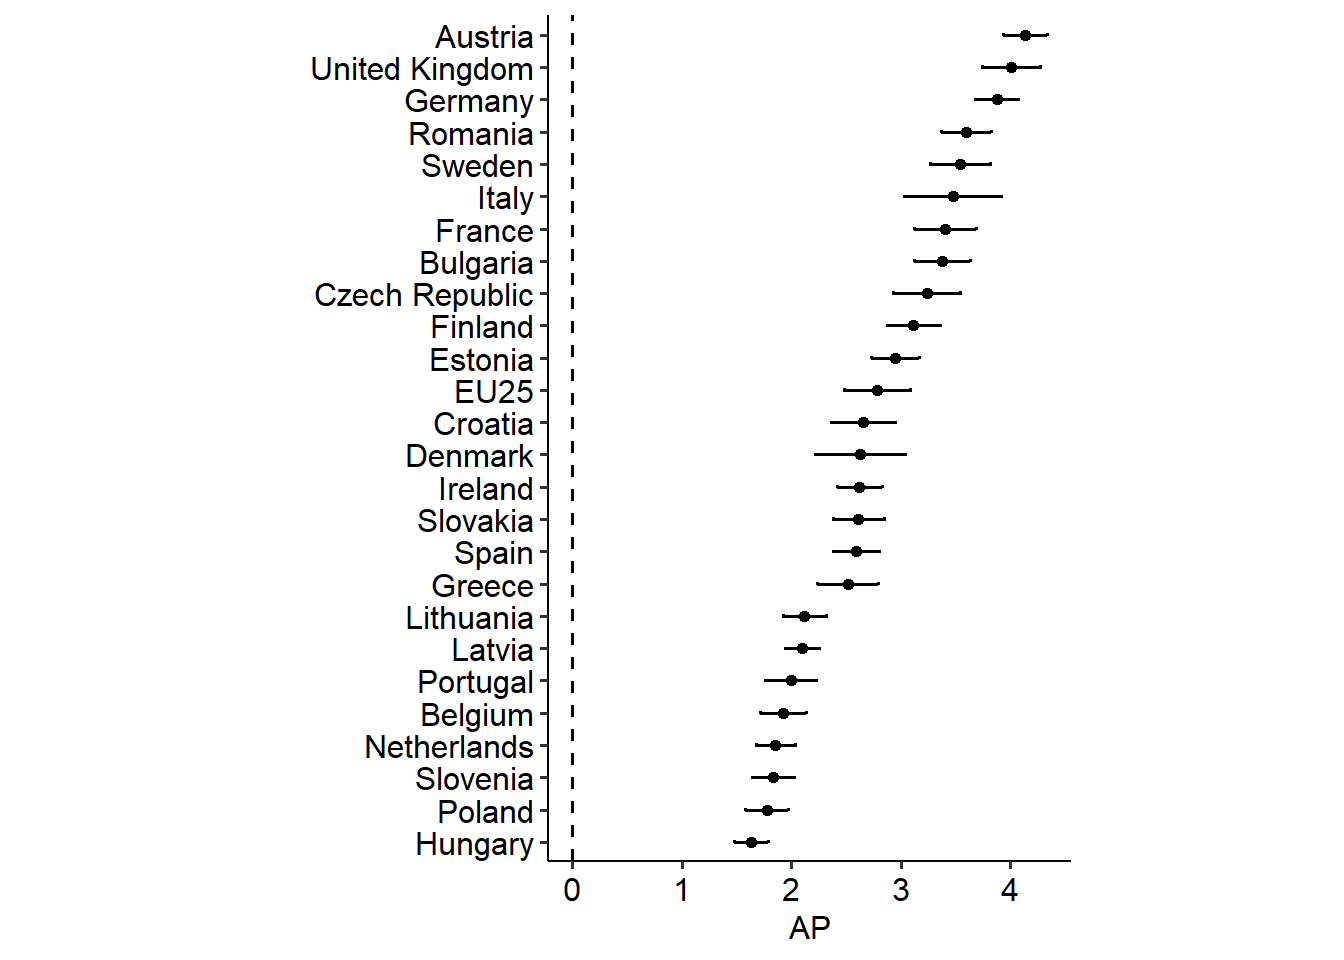

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Implicit",
    measure_id == "Attitudinal API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Explicit

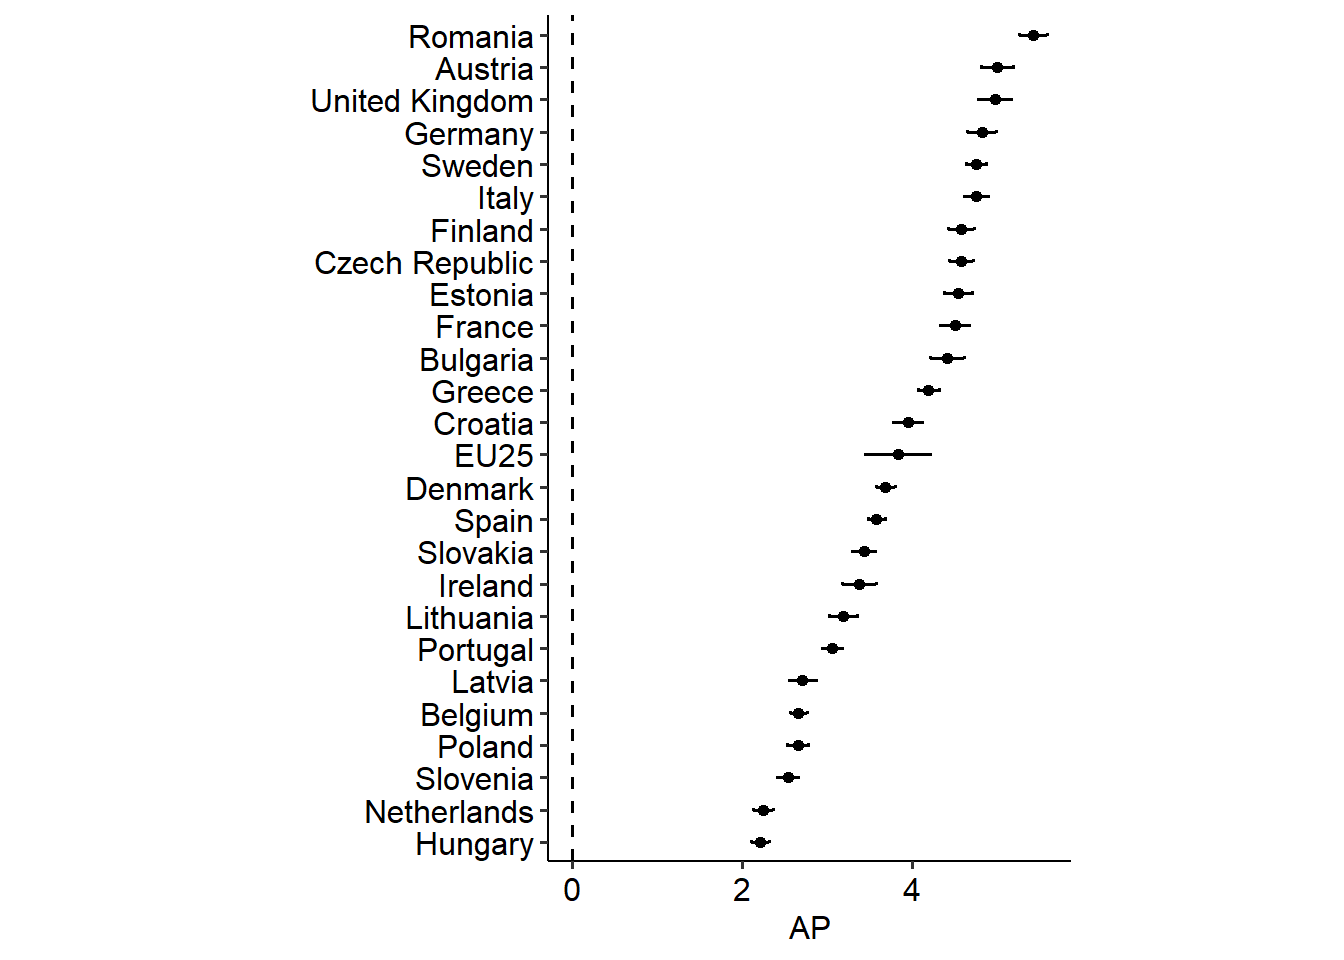

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Explicit",
    measure_id == "Attitudinal API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Total

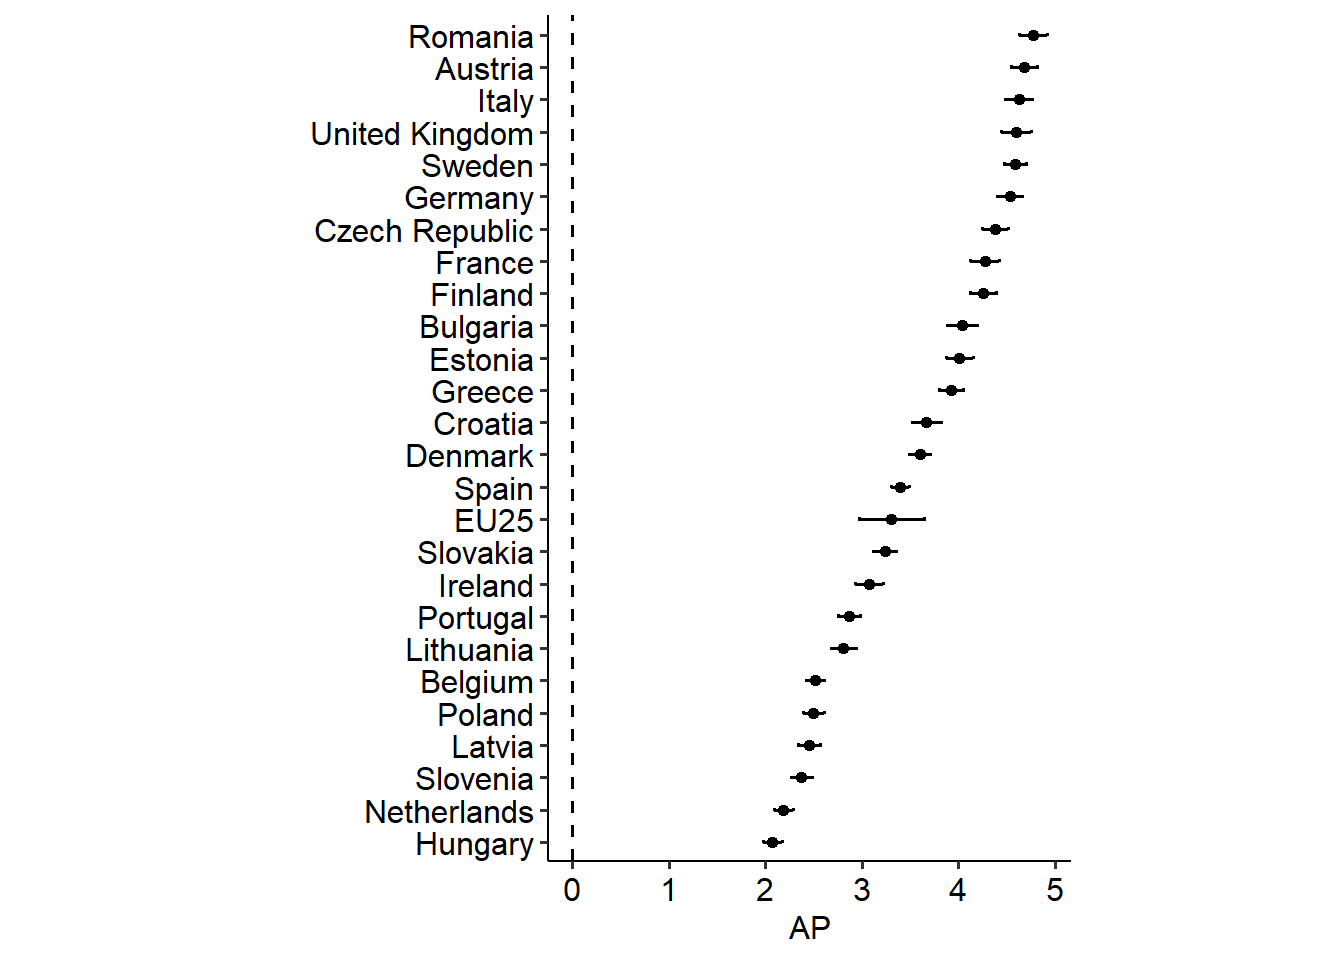

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Total",
    measure_id == "Attitudinal API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Attitudinal Distance

## Implicit

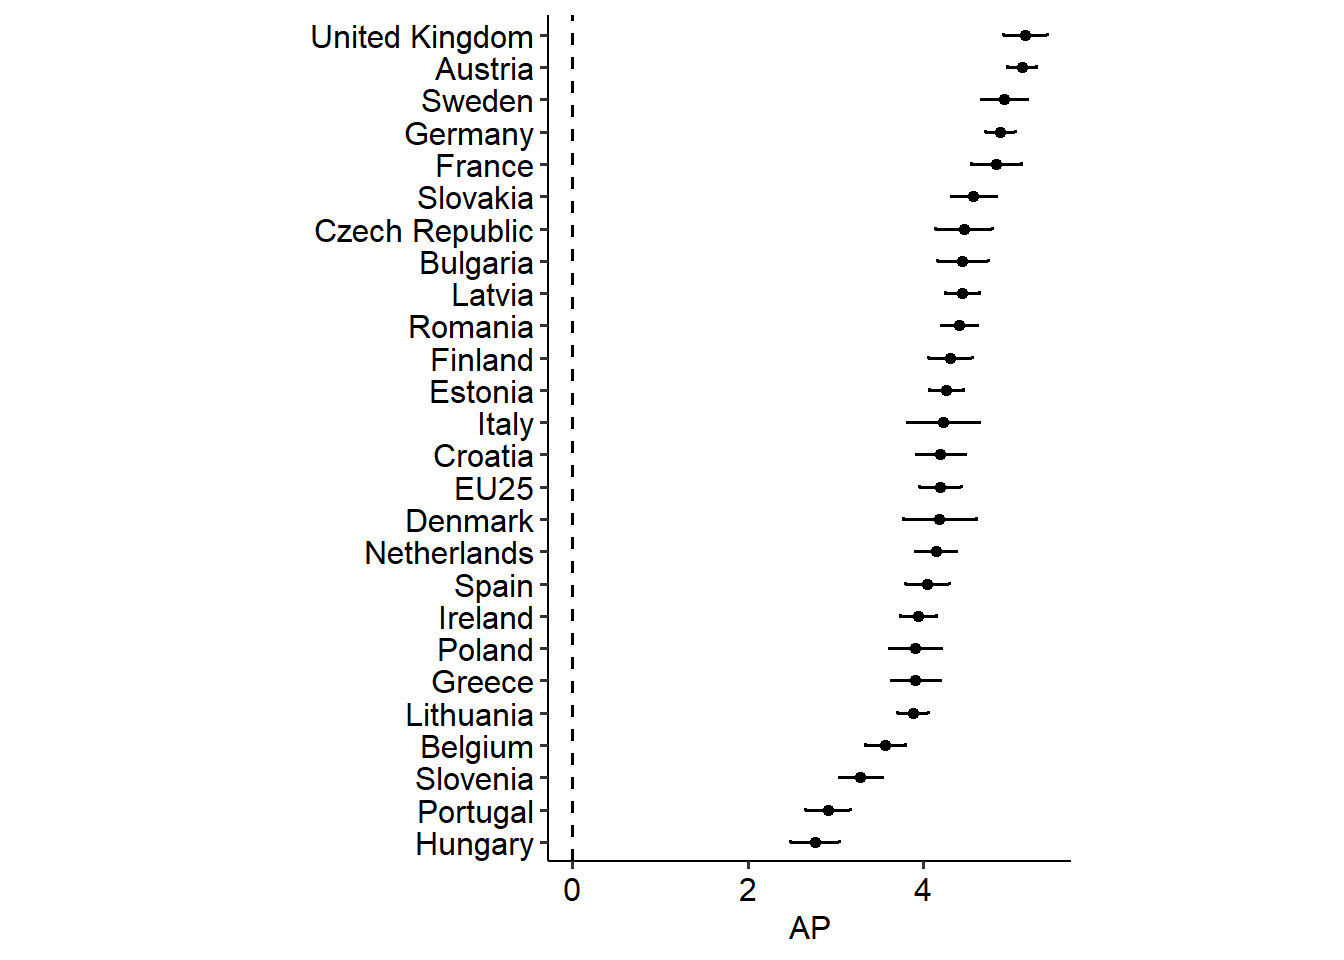

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Implicit",
    measure_id == "Attitudinal Distance",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Explicit

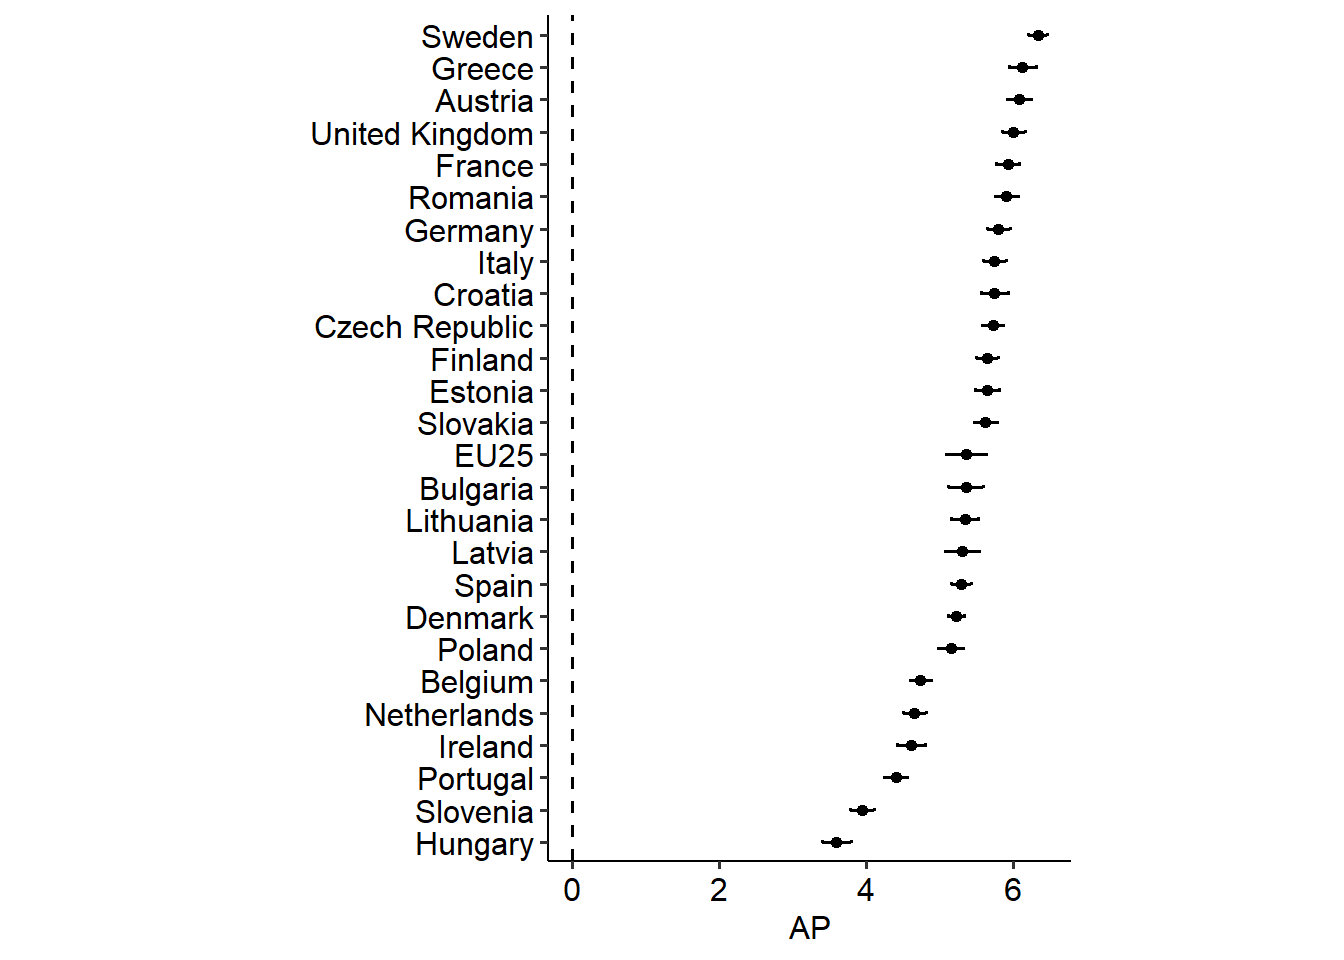

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Explicit",
    measure_id == "Attitudinal Distance",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Total

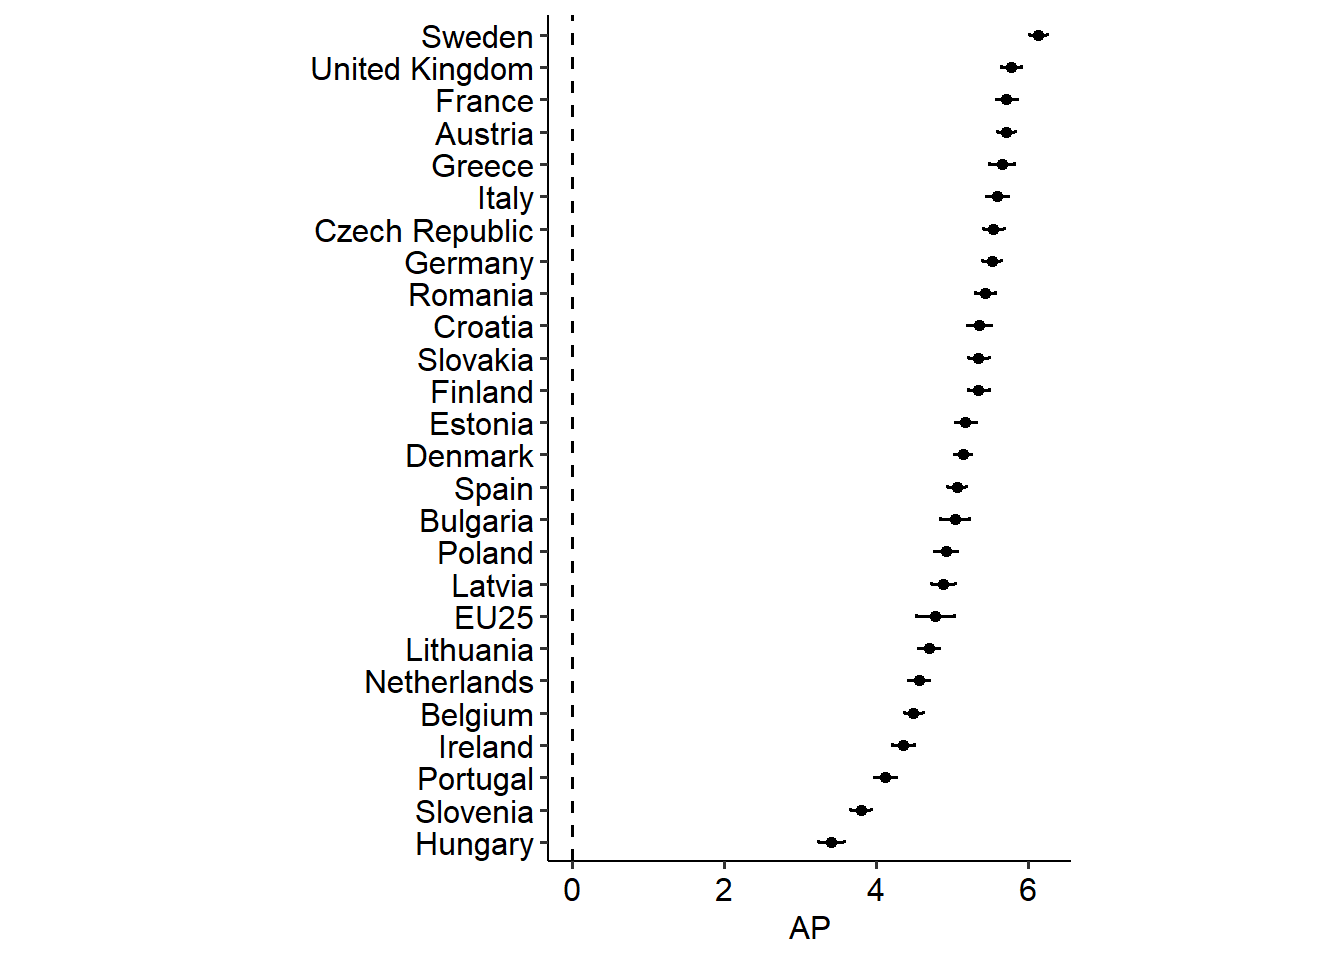

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Total",
    measure_id == "Attitudinal Distance",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Non-Partisans

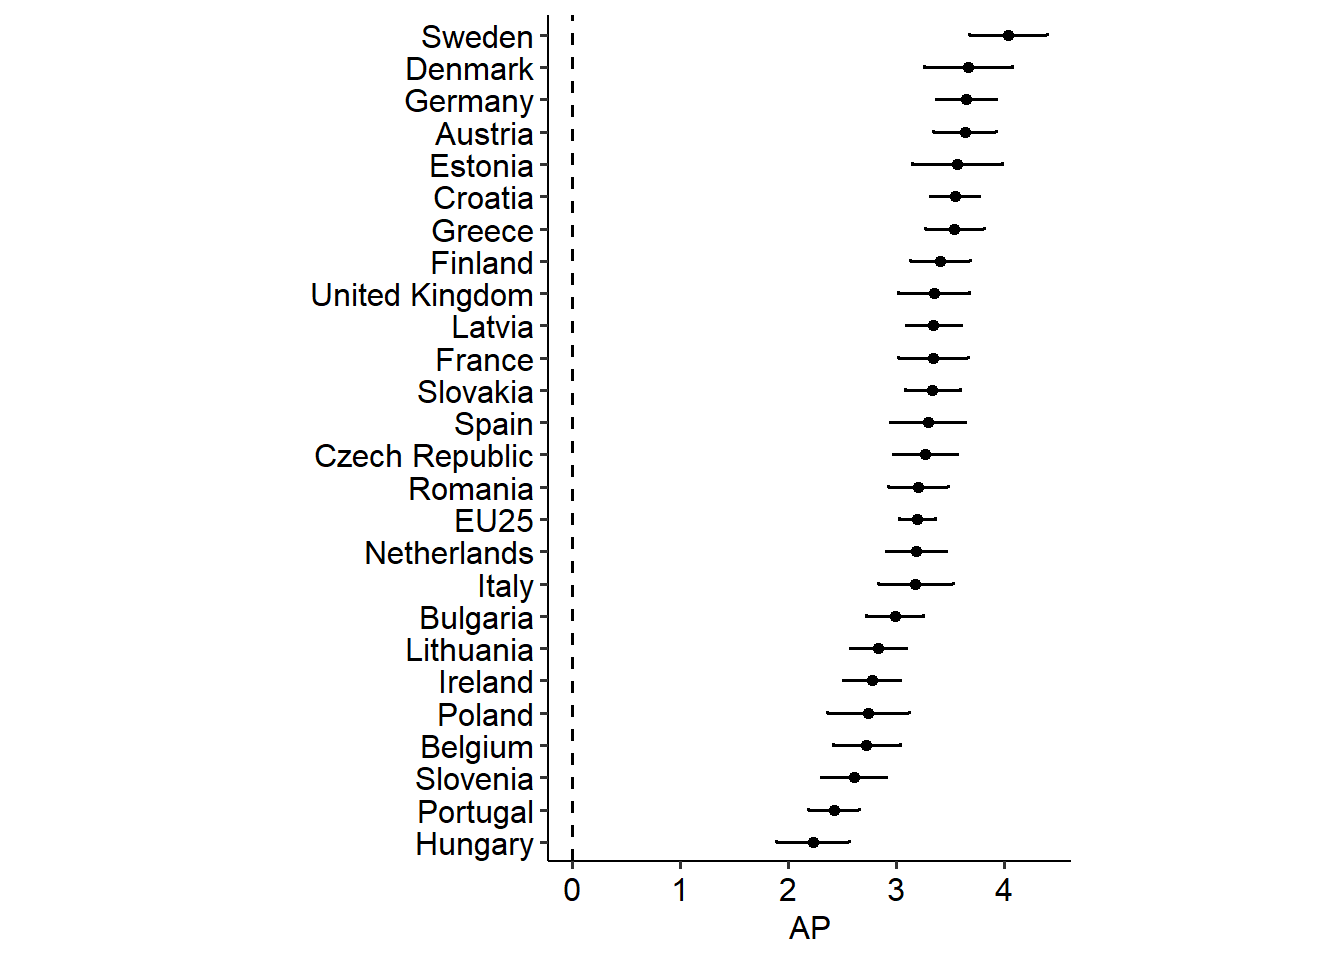

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Non-Partisan",
    measure_id == "Attitudinal Distance",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Attitudinal Spread

## Implicit

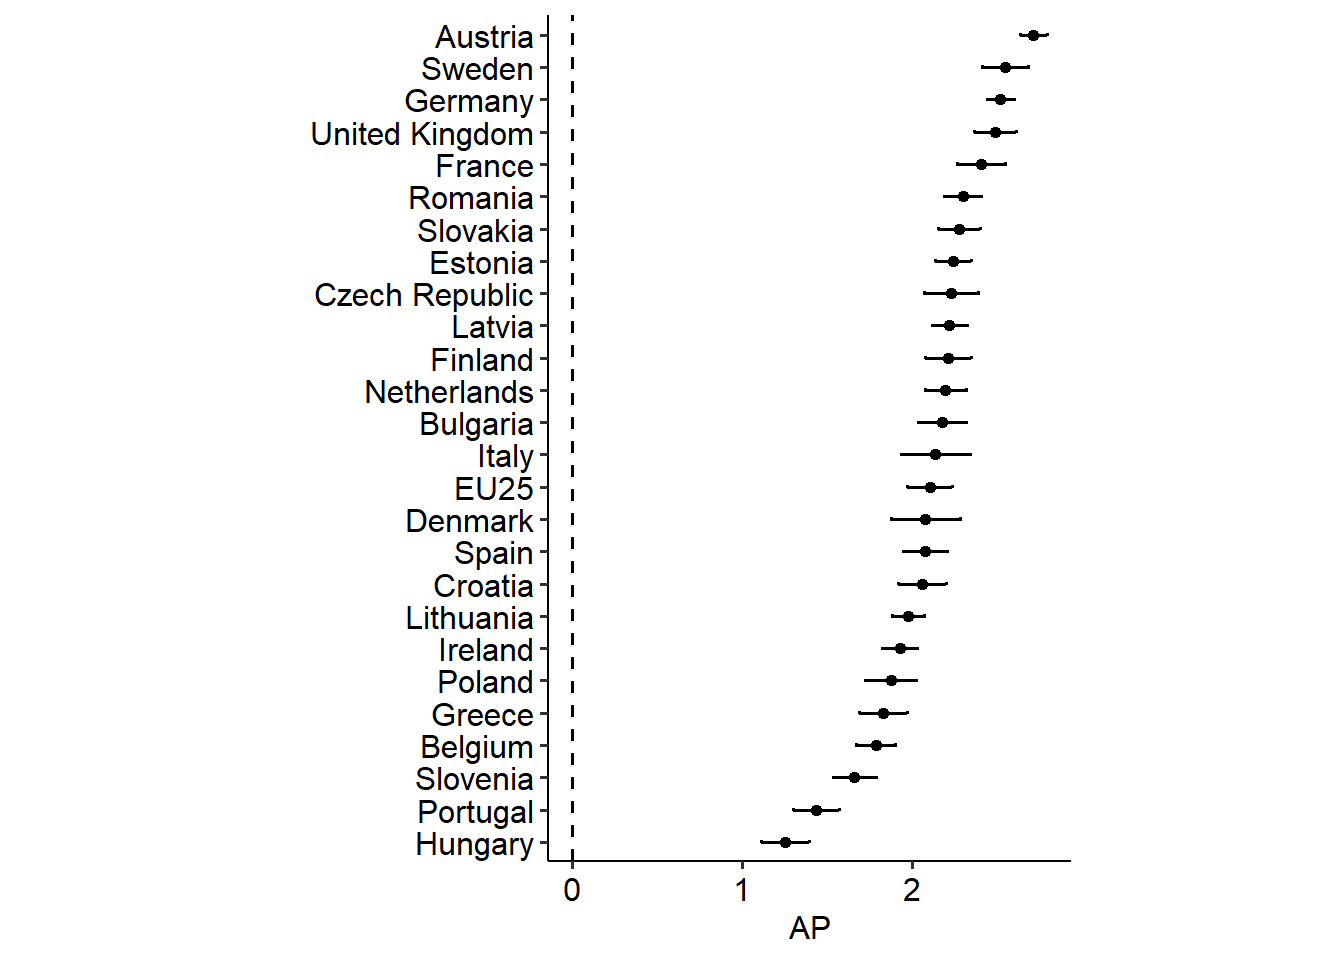

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Implicit",
    measure_id == "Attitudinal Spread",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Explicit

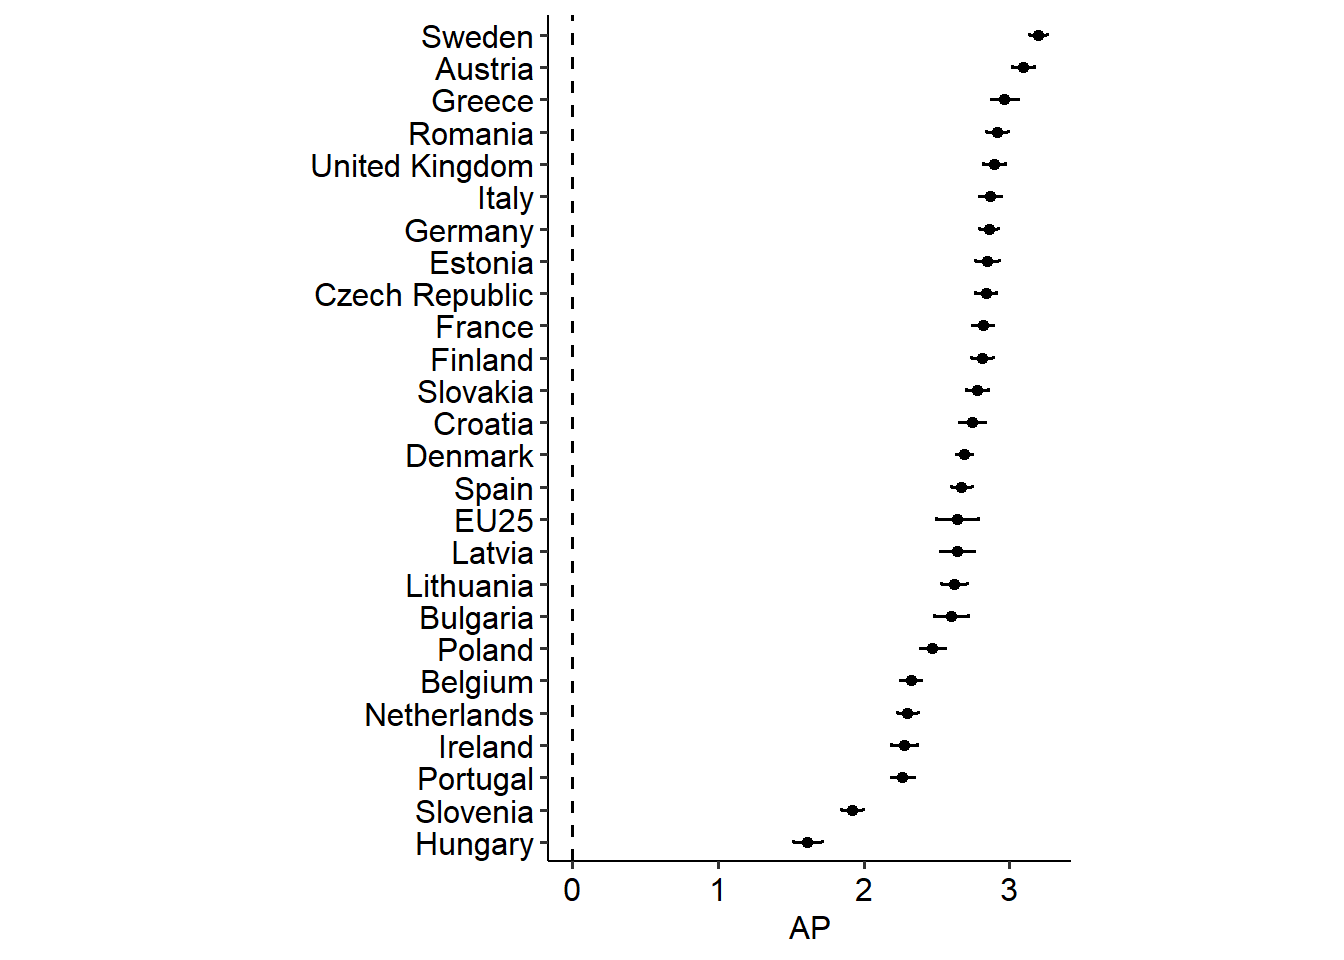

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Explicit",
    measure_id == "Attitudinal Spread",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Total

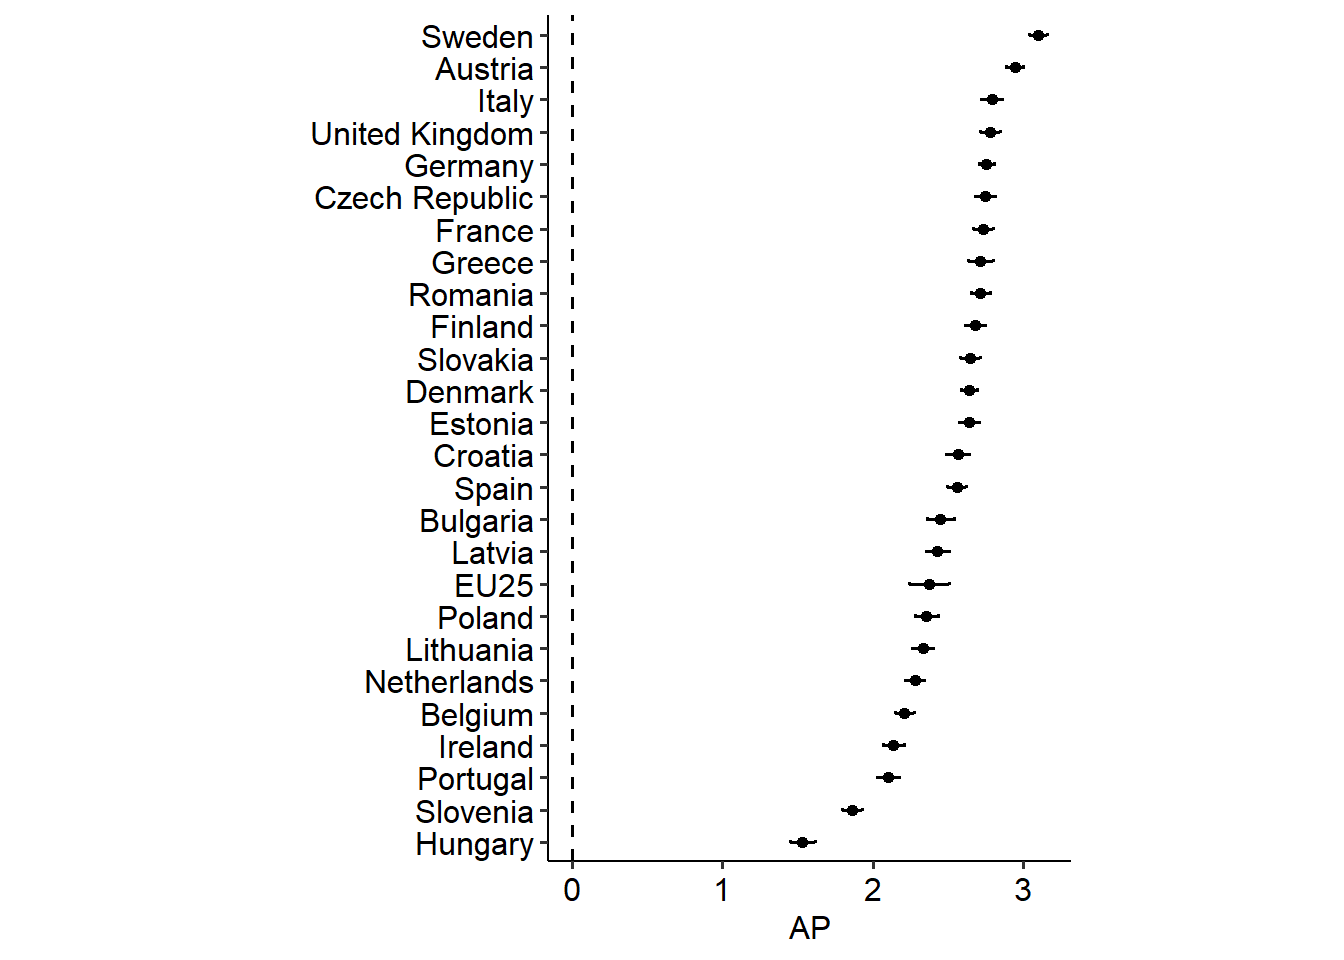

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Total",
    measure_id == "Attitudinal Spread",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


## Non-Partisans

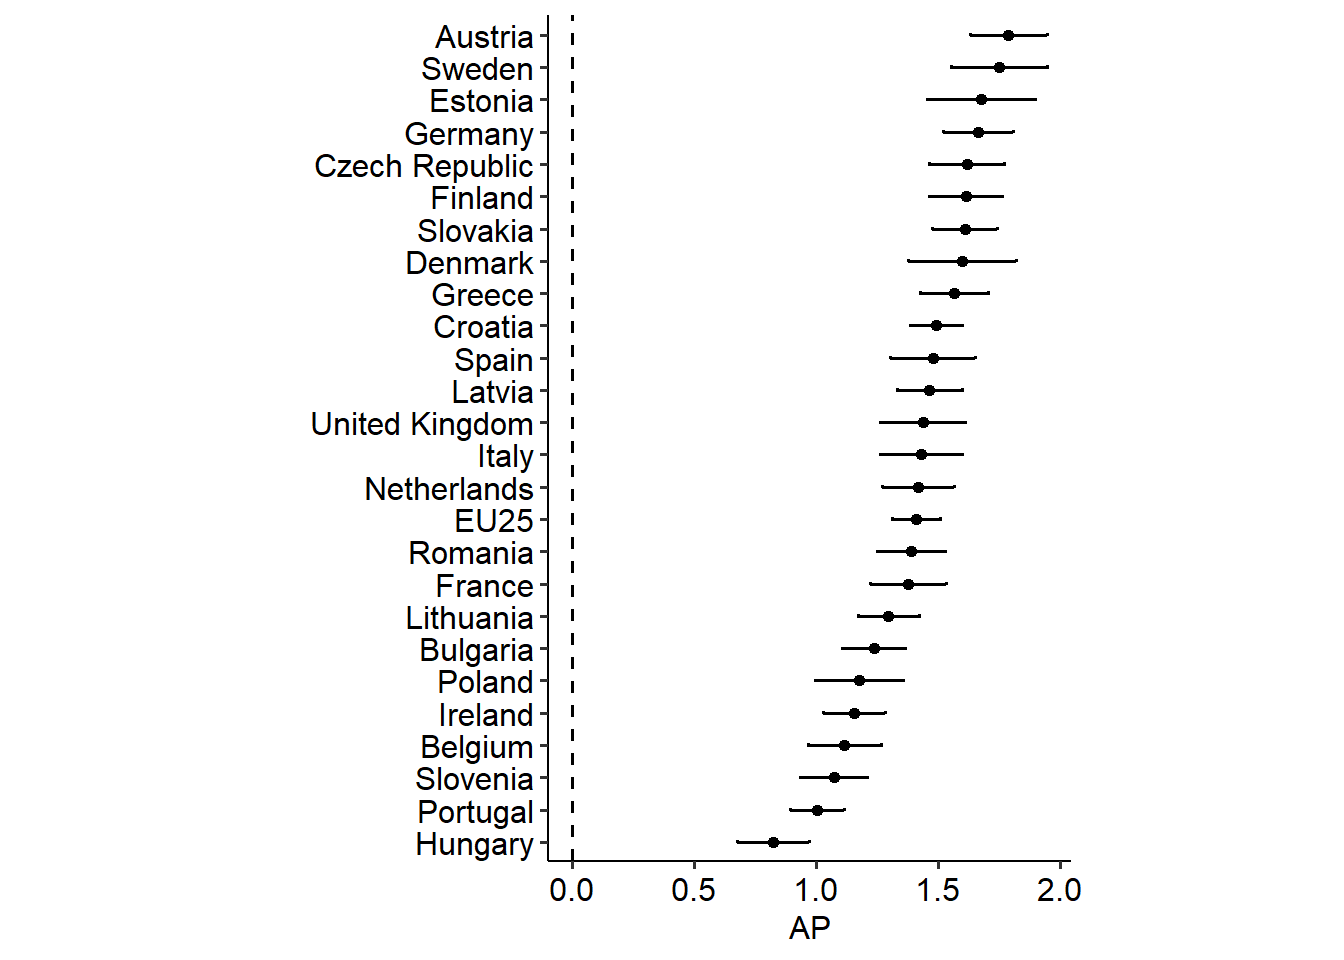

In [ ]:

expl_res_w |>
  filter(
    der_partisan_type == "Non-Partisan",
    measure_id == "Attitudinal Spread",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)


In [ ]:

# Unique options for dropdowns
partisan_types <- unique(expl_res_w$der_partisan_type)
measure_ids <- unique(expl_res_w$measure_id)

ui <- fluidPage(
  titlePanel("Country Rankings by AP"),

  sidebarLayout(
    sidebarPanel(
      selectInput(
        "type",
        "Select partisan type for sorting:",
        choices = partisan_types,
        selected = "Implicit"
      ),
      selectInput(
        "measure",
        "Select measure_id:",
        choices = measure_ids,
        selected = "Behavioral API"
      )
    ),

    mainPanel(
      plotOutput("ap_plot", height = "800px")
    )
  )
)

server <- function(input, output) {
  output$ap_plot <- renderPlot({
    # Filter and reorder based on user selection
    expl_res_w %>%
      filter(
        der_partisan_type == input$type,
        measure_id == input$measure
      ) %>%
      mutate(meta_country = fct_reorder(meta_country, ap)) %>%
      ggplot(aes(x = ap, y = meta_country)) +
      geom_point() +
      geom_errorbar(aes(xmin = ci_low, xmax = ci_high), width = 0.1) +
      geom_vline(xintercept = 0, linetype = "dashed") +
      labs(
        y = "",
        x = "AP",
        shape = "Partisan Type",
        color = "Partisan Type"
      ) +
      theme_pubr() +
      theme(aspect.ratio = 1.618 / 1)
  })
}

shinyApp(ui, server)


# Session Info

In [ ]:

session_info()


Warning in system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=", :
running command '"quarto"
TMPDIR=C:/Users/Tris/AppData/Local/Temp/RtmpAJ0Xxr/file4dec251c331a -V' had
status 1

─ Session info ───────────────────────────────────────────────────────────────
 setting  value
 version  R version 4.5.2 (2025-10-31 ucrt)
 os       Windows 11 x64 (build 26200)
 system   x86_64, mingw32
 ui       RTerm
 language (EN)
 collate  English_United States.utf8
 ctype    English_United States.utf8
 tz       Europe/Berlin
 date     2026-02-11
 pandoc   3.6.3 @ c:\\Program Files\\Positron\\resources\\app\\quarto\\bin\\tools/ (via rmarkdown)
 quarto   NA @ C:\\PROGRA~1\\Positron\\RESOUR~1\\app\\quarto\\bin\\quarto.exe

─ Packages ───────────────────────────────────────────────────────────────────
 ! package      * version date (UTC) lib source
 P abind          1.4-8   2024-09-12 [?] CRAN (R 4.5.0)
 P backports      1.5.0   2024-05-23 [?] CRAN (R 4.5.0)
 P broom          1.0.11  2025-12-04 [?] CRAN (R 4.5.2)
 P car            3.1-3   2024-09-27 [?] CRAN (R 4.5.1)
 P carData        3.0-5   2022-01-06 [?] CRAN (R 4.5.1)
 P cli            3.6.5   2025-04-23 [?] CRAN (R 4.5.1)
 P di

# Render Time

In [ ]:

end_time <- Sys.time()

rendering_time <- end_time - start_time

message(paste(
  "Document rendered in:",
  round(as.numeric(rendering_time, units = "secs"), 2),
  "seconds.
"
))


Document rendered in: 48.37 seconds.

```` markdown
---
title: |
  Code Notebook 3.2
subtitle: |
  AP Measures
date: last-modified
date-format: MMMM D, YYYY
format:
  html:
    toc: true
    code-fold: true
    code-tools: true
    embed-resources: true
execute:
  echo: true
  warning: true
  eval: true
  message: true
---

# Setup

quarto-executable-code-5450563D

```r
#| label: setup

# To track render duration
start_time <- Sys.time()

# set width of console output
options(width = 80)


# Install and load required packages
p_required <- c(
  "tidyverse",
  "here",
  "ggpubr", # theme_pubr()
  "sessioninfo"
)
packages <- rownames(installed.packages())
p_to_install <- p_required[!(p_required %in% packages)]
if (length(p_to_install) > 0) {
  install.packages(p_to_install)
}
sapply(p_required, require, character.only = TRUE)
rm(p_required, p_to_install, packages)
```

# Load Data

quarto-executable-code-5450563D

```r
#| label: load-data

eu25games2019 <- readRDS(
  file = here(
    "data",
    "03_final",
    "eu25games2019.rds"
  )
)
```

# Overview of Measures

For our behavioral experiment, we conceptually draw from Reiljan's API.
Formally, we define AP as the difference in tokens allocated to the ingroup, minus the average number of tokens allocated to all outgroups. 

Weighted and unweighted

For the thermometer score, we calculate three measures, each weighted and unweighted:

Reiljan API
Wagner Mean Distance
Wagner Spread of Scores

We compare the levels across identifiers, voters (without identity) and nonpartisans (Wagner)

# Party sizes (for weighting)

What to use, empirical distributions in sample (id/vote?) or electoral vote share in 2019? Both?

quarto-executable-code-5450563D

```r
#| label: party-shares-vote-variable

# relative (reported) vote shares
votes_per_country <- eu25games2019 |>
  select(
    meta_country,
    meta_pid,
    der_vote_combined_name
  ) |>
  distinct(meta_pid, .keep_all = T) |>
  filter(
    der_vote_combined_name != "dont-know" &
      der_vote_combined_name != "other"
  ) |>
  group_by(meta_country, der_vote_combined_name) |>
  count(der_vote_combined_name) |>
  ungroup() |>
  group_by(meta_country) |>
  summarise(
    abs_vote = sum(n)
  )

votes_per_party <- eu25games2019 |>
  select(
    meta_country,
    meta_pid,
    der_vote_combined_name
  ) |>
  distinct(meta_pid, .keep_all = T) |>
  filter(
    der_vote_combined_name != "dont-know" &
      der_vote_combined_name != "other"
  ) |>
  group_by(meta_country, der_vote_combined_name) |>
  count(der_vote_combined_name) |>
  ungroup()

votes_per_party <- votes_per_party |>
  left_join(
    votes_per_country,
    by = join_by(meta_country)
  )

votes_per_party <- votes_per_party |>
  mutate(
    der_anchor_vote_share = n / abs_vote
  )

eu25games2019 <- eu25games2019 |>
  left_join(
    (votes_per_party |>
      select(
        der_vote_combined_name,
        der_anchor_vote_share
      )),
    by = join_by(der_partisan_anchor == der_vote_combined_name)
  )
```

# Target Table (Pooled Descriptive Analyses)

What I want is a tibble in the format (or do I?)

| Measurement | measure | weighted | der_partisan_type | ap | ci_low | ci_high | 
|:--|:--------|:---------|:------------------|---:|-------:|--------:|
| Behavioral | API | N | Explicit | X | X | X |
| Behavioral | API  | N | Implicit | X | X | X |
| Behavioral | API  | N | Total | X | X | X |
| Behavioral | API  | Y | Explicit | X | X | X |
| Behavioral | API  | Y | Implicit | X | X | X |
| Behavioral | API  | Y | Total | X | X | X |
| Attitudinal | API  | N | Explicit | X | X | X |
| Attitudinal | API  | N | Implicit | X | X | X |
| Attitudinal | API  | N | Total | X | X | X |
| Attitudinal | API  | Y | Explicit | X | X | X |
| Attitudinal | API  | Y | Implicit | X | X | X |
| Attitudinal | API  | Y | Total | X | X | X |
| Attitudinal | Mean Dist. | N | Explicit | X | X | X |
| Attitudinal | Mean Dist. | N | Implicit | X | X | X |
| Attitudinal | Mean Dist. | N | None | X | X | X |
| Attitudinal | Mean Dist. | N | Total | X | X | X |
| Attitudinal | Mean Dist. | Y | Explicit | X | X | X |
| Attitudinal | Mean Dist. | Y | Implicit | X | X | X |
| Attitudinal | Mean Dist. | Y | None | X | X | X |
| Attitudinal | Mean Dist. | Y | Total | X | X | X |
| Attitudinal | Spread | N | Explicit | X | X | X |
| Attitudinal | Spread | N | Implicit | X | X | X |
| Attitudinal | Spread | N | None | X | X | X |
| Attitudinal | Spread | N | Total | X | X | X |
| Attitudinal | Spread | Y | Explicit | X | X | X |
| Attitudinal | Spread | Y | Implicit | X | X | X |
| Attitudinal | Spread | Y | None | X | X | X |
| Attitudinal | Spread | Y | Total | X | X | X |

# Aggregated AP: Token Allocation

We measure affective polarization as the difference in expected token allocations to co-partisans and out-partisans. Expectations are taken over all conjoint profiles presented to respondents, such that the out-partisan category averages across all non-anchor parties. This operationalization is conceptually equivalent to Reiljan's affective polarization index (API), adapted to behavioral outcomes.

$$
\text{AP} = \mathbb{E}(\text{Token} \mid \text{Co}) - \mathbb{E}(\text{Token} \mid \text{Out})
$$ {#eq-eu25-ap-cj}

quarto-executable-code-5450563D

```r
#| label: eu25-ap-cj-unweighted

pooled_ap_cj <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type)
  ) |>
  group_by(der_partisan_type, der_partisan_relationship) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap = mean_Co - mean_Out,
    se = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      .default = NA
    )
  )


total_pooled_ap_cj <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type)
  ) |>
  group_by(der_partisan_relationship) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap = mean_Co - mean_Out,
    se = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se
  ) |>
  mutate(der_partisan_type = "Total") |>
  relocate(der_partisan_type, .before = mean_Co)

pooled_ap_cj <- pooled_ap_cj |>
  bind_rows(total_pooled_ap_cj) |>
  mutate(measure = "Token")

pooled_ap_cj <- pooled_ap_cj |>
  select(
    der_partisan_type,
    ap,
    ci_low,
    ci_high
  ) |>
  mutate(
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    weighted = 0,
  )
```

To account for cross-national differences in party system composition, we compute party-specific affective polarization within each country and weight these differences by parties' empirical vote shares in our data. Party weights sum to one within countries, ensuring that affective polarization reflects the relative electoral importance of parties in the national party system.

European affective polarization is obtained by aggregating country-level affective polarization scores. Each country contributes equally to the European estimate, preventing countries with larger samples or more fragmented party systems from exerting disproportionate influence.

$$
\text{AP}_{c}
=
\sum_{p \in c}
w_{pc}
\, \text{AP}_{pc},
\qquad
\sum_{p \in c} w_{pc} = 1
$$ {#eq-eu25-ap-country-weighted}

$$
\text{AP}_{EU}
=
\frac{1}{C}
\sum_{c=1}^{C}
\text{AP}_{c}
$$ {#eq-eu25-ap-europe}



quarto-executable-code-5450563D

```r
#| label: eu25-ap-cj-weighted

ap_country_party <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type),
    !is.na(der_anchor_vote_share)
  ) |>
  group_by(
    meta_country,
    der_partisan_type,
    der_partisan_anchor,
    der_partisan_relationship
  ) |>
  summarise(
    mean = mean(cj_token),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = mean
  ) |>
  mutate(
    ap_party = Co - Out
  )

ap_country_weighted <- eu25games2019 |>
  distinct(
    meta_country,
    der_partisan_anchor,
    der_anchor_vote_share
  ) |>
  right_join(
    ap_country_party,
    by = c("meta_country", "der_partisan_anchor")
  ) |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap_country = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),
    .groups = "drop"
  )

ap_europe <- ap_country_weighted |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    weighted = 1,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      .default = NA
    )
  ) |>
  select(
    -se
  )

# Again for total AP (no distinguishing type) ----------------------------------
ap_country_party_total <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type),
    !is.na(der_anchor_vote_share)
  ) |>
  group_by(
    meta_country,
    der_partisan_anchor,
    der_partisan_relationship
  ) |>
  summarise(
    mean = mean(cj_token),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = mean
  ) |>
  mutate(
    ap_party = Co - Out
  )

ap_country_weighted_total <- eu25games2019 |>
  distinct(
    meta_country,
    der_partisan_anchor,
    der_anchor_vote_share
  ) |>
  right_join(
    ap_country_party_total,
    by = c("meta_country", "der_partisan_anchor")
  ) |>
  group_by(meta_country) |>
  summarise(
    ap_country = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),
    .groups = "drop"
  )

ap_europe_total <- ap_country_weighted_total |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    weighted = 1,
    der_partisan_type = "Total"
  ) |>
  select(
    -se
  )

pooled_ap_cj <- pooled_ap_cj |>
  bind_rows(ap_europe, ap_europe_total)
```


# Aggregated AP: Thermometer Scores

quarto-executable-code-5450563D

```r
#| label: thermometer-long-format

# turn thermoscores to long format
thermo_long <- eu25games2019 |>
  select(
    meta_country,
    meta_pid,
    der_partisan_type,
    der_partisan_anchor,
    matches("^q_thermo_[0-9]+$"),
    matches("^ext_q_thermo_[0-9]+_pf_name$")
  ) |>
  distinct(meta_pid, .keep_all = T) |>
  pivot_longer(
    cols = matches("^(q_thermo_|ext_q_thermo_)[0-9]+"),
    names_to = c(".value", "slot"),
    names_pattern = "(q_thermo|ext_q_thermo)_(\\d+)"
  ) |>
  rename(
    thermo_score = q_thermo,
    thermo_party = ext_q_thermo
  ) |>
  filter(!is.na(thermo_score), !is.na(thermo_party)) |>
  mutate(thermo_score = thermo_score / 10) |>
  select(
    meta_country,
    meta_pid,
    der_partisan_type,
    der_partisan_anchor,
    thermo_party,
    thermo_score
  )

```


quarto-executable-code-5450563D

```r
#| label: fig-distr-thermo
#| fig-cap: "Distribution of thermometer ratings (rescaled from 0-100 to 0-10). $Mean = 3.89$, $median = 4$, $SD = 3.04$"

summary_stats <- thermo_long |>
  summarise(
    mean_thermo = mean(thermo_score, na.rm = TRUE),
    median_thermo = median(thermo_score, na.rm = TRUE),
    sd_thermo = sd(thermo_score, na.rm = TRUE)
  )

thermo_long |>
  ggplot(
    aes(x = thermo_score)
  ) +
  geom_histogram(
    color = "black",
    fill = "white"
  ) +
  scale_x_continuous(
    breaks = 0:10,
    labels = 0:10
  ) +
  labs(
    x = "Thermo Score",
    y = "N"
  ) +
  ggpubr::theme_pubr()
```


There are three main operationalization strategies applied in European AP studies: Reiljan's API, Wagner's mean distance and Wagner's average spread.

## API

The full **Affective Polarization Index** (Reiljan 2020):

$$
\text{API} = \sum_{n=1}^{N} \left[ \sum_{\substack{m = 1\\ m \neq n}}^{N} \left( (Like_n - Like_m) \times \left(\frac{\text{Vote share}_{m}}{1 - \text{Vote share}_{n}} \right) \right) \times \text{Vote share}_n \right]
$$


quarto-executable-code-5450563D

```r
#| label: eu25-reiljan-api

# calculate individual level AP
api_individual <- thermo_long |>
  mutate(
    ingroup = thermo_party == der_partisan_anchor
  ) |>
  group_by(meta_pid, der_partisan_type) |>
  summarise(
    mean_Co = mean(thermo_score[ingroup], na.rm = TRUE),
    mean_Out = mean(thermo_score[!ingroup], na.rm = TRUE),
    api = mean_Co - mean_Out,
    n_Co = sum(ingroup),
    n_Out = sum(!ingroup),
    .groups = "drop"
  ) |>
  filter(n_Co > 0, n_Out > 0)


pooled_ap_thermo <- api_individual |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(api),
    sd_ap = sd(api),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 0,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      .default = NA
    )
  )


total_ap_thermo <- api_individual |>
  summarise(
    ap = mean(api),
    sd_ap = sd(api),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 0,
    der_partisan_type = "Total"
  ) |>
  relocate(der_partisan_type, .before = ap)

pooled_ap_thermo <- bind_rows(pooled_ap_thermo, total_ap_thermo) |>
  select(
    -sd_ap,
    -n_ap,
    -se_ap
  )

```

quarto-executable-code-5450563D

```r
#| label: eu25-reiljan-api-weighted

api_party <- thermo_long |>
  filter(!is.na(der_partisan_type)) |>
  mutate(ingroup = thermo_party == der_partisan_anchor) |>
  group_by(meta_country, der_partisan_type, der_partisan_anchor) |>
  summarise(
    mean_Co = mean(thermo_score[ingroup], na.rm = TRUE),
    mean_Out = mean(thermo_score[!ingroup], na.rm = TRUE),
    ap_party = mean_Co - mean_Out,
    .groups = "drop"
  )

api_party <- api_party |>
  left_join(
    votes_per_party |>
      select(
        der_vote_combined_name,
        der_anchor_vote_share
      ),
    by = join_by(
      der_partisan_anchor == der_vote_combined_name
    )
  )

ap_country_weighted <- api_party |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap_country = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),
    .groups = "drop"
  )

ap_europe_weighted <- ap_country_weighted |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 1,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit"
    )
  ) |>
  select(-se)

# For all partisans combined ---------------------------------------------------
api_party_total <- api_party |>
  group_by(meta_country, der_partisan_anchor) |>
  summarise(
    ap_party_total = mean(ap_party, na.rm = TRUE), # collapse across types
    .groups = "drop"
  )

ap_country_weighted_total <- api_party_total |>
  left_join(
    votes_per_party |>
      select(
        der_vote_combined_name,
        der_anchor_vote_share
      ),
    by = join_by(
      der_partisan_anchor == der_vote_combined_name
    )
  ) |>
  group_by(meta_country) |>
  summarise(
    ap_country = sum(ap_party_total * der_anchor_vote_share, na.rm = TRUE),
    .groups = "drop"
  )

ap_europe_weighted_total <- ap_country_weighted_total |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 1,
    der_partisan_type = "Total"
  ) |>
  select(-se)


pooled_ap_thermo_weighted <- bind_rows(
  ap_europe_weighted,
  ap_europe_weighted_total
)

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_thermo_weighted)
```

## Preliminary Figure

Weighting affective polarization by parties' electoral size increases uncertainty when the underlying measure is noisy. For thermometer-based (attitudinal) AP, upweighting small or under-sampled parties amplifies individual-level variability, producing slightly wider confidence intervals. Behavioral token allocations are lower-variance, so weighting has little effect on their uncertainty.

quarto-executable-code-5450563D

```r
#| label: fig-eu25-ap
#| fig-cap: "Affective Polarization in EU25 (2019). Note: 1) Explicit: Reported Attachement; Implicit: Denied Attachement but Reported Vote; Total: All Partisans (Expl. and Impl.). 2) Errorbars represent 95\\% CI. 3) Weighted estimates and errorbars are based on empirical distribution of reported votes in our data. 4) Behavioral Scale (Token): -10 (10 Token allocated to Out-Party and none to Co-Party) to +10 (10 Token allocated to Co-party and 0 to Out-Party); Attitudinal Scale (Thermo): -10 (Thermoscore 10 for Out-Party and 0 for Co-Party) to +10 (Thermoscore 10 for Co-Party and 0 for Out-Party)."
#| fig-dpi: 500
#| fig-pos : H

toplot <- bind_rows(
  pooled_ap_cj,
  pooled_ap_thermo
)

ggplot(
  toplot,
  aes(
    x = ap,
    y = der_partisan_type,
    shape = factor(weighted),
    color = measurement
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = ifelse(toplot$weighted == 1, 0.1, -0.1))
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = ifelse(toplot$weighted == 1, 0.1, -0.1)),
    width = 0.1
  ) +
  labs(
    y = "Sample",
    x = "AP",
    shape = "Party Weight",
    color = "Measurement"
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618)

```

... to be continued with Wagners measures

## Spread of like-dislike scores

[I]t is the average absolute party like-dislike difference relative to each respondent's average party like-dislike score

$$
\text{Spread}_i = \sqrt{ \frac{ \sum_{p=1}^{P} ( \text{like}_{ip} - \overline{\text{like}}_{i})^2 } {n_p}}
$$

quarto-executable-code-5450563D

```r
#| label: eu25-wagner-spread

# Calculate Spread per respondent
api_spread_individual <- thermo_long |>
  group_by(meta_pid, der_partisan_type) |>
  summarise(
    # Wagner's Spread is the standard deviation of all party evaluations for individual i
    spread_score = sd(thermo_score, na.rm = TRUE),
    n_parties = n(),
    .groups = "drop"
  ) |>
  # Filter for respondents who rated at least 2 parties
  filter(n_parties >= 2, !is.na(spread_score))

# Aggregate by Partisan Type
pooled_ap_spread <- api_spread_individual |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

# Aggregate for Total
total_ap_spread <- api_spread_individual |>
  filter(!is.na(der_partisan_type)) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(der_partisan_type = "Total")

# Combine and format for toplot
pooled_ap_spread <- bind_rows(pooled_ap_spread, total_ap_spread) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Spread",
    outcome = "Thermo Score",
    weighted = 0
  ) |>
  select(
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_spread)
```

The Weighted Affective Polarization (WAP) equation for parties $j$ and voter $i$ is:

$$
\text{Spread}_i = \sqrt{ \sum_{p=1}^{P} v_p ( \text{like}_{ip} - \overline{\text{like}}_{i})^2 }
$$

$v_p$ is the vote share of each party, measured as a proportion with a range from 0 to 1.
The mean affect should itself be weighted by party size and is calculated as:

$$
\overline{like}_i = \sum_{p=1}^{p} ( v_p * \text{like}_{ip})
$$

quarto-executable-code-5450563D

```r
#| label: eu25-wagner-spread-weighted

# 1. Attach party vote shares (v_p) to every evaluation
thermo_weighted_ind <- thermo_long |>
  left_join(
    votes_per_party |>
      select(meta_country, der_vote_combined_name, v_p = der_anchor_vote_share),
    by = c("meta_country", "thermo_party" = "der_vote_combined_name")
  ) |>
  filter(!is.na(v_p), !is.na(thermo_score))

# 2. Calculate Individual Weighted Spread using your formulas
api_spread_weighted_ind <- thermo_weighted_ind |>
  group_by(meta_pid, der_partisan_type, meta_country) |>
  summarise(
    # Formula: Mean like = sum(v_p * like)
    # Note: sum(v_p) might be < 1 if not all parties were rated, so we normalize
    w_sum_v = sum(v_p),
    weighted_mean = sum(v_p * thermo_score) / w_sum_v,

    # Formula: Spread = sqrt( sum( v_p * (like - mean)^2 ) )
    # Again, normalizing by sum(v_p) ensures the weighted variance is scale-correct
    spread_score = sqrt(sum(v_p * (thermo_score - weighted_mean)^2) / w_sum_v),
    n_parties = n(),
    .groups = "drop"
  ) |>
  filter(n_parties >= 2)

# 3. Aggregate for the European Level (Country-Averaging)
# We aggregate to country first to ensure each country contributes equally
ap_country_spread_w <- api_spread_weighted_ind |>
  group_by(meta_country, der_partisan_type) |>
  summarise(ap_country = mean(spread_score), .groups = "drop")

# 4. Final European Scores
ap_europe_spread_weighted <- ap_country_spread_w |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

# 5. Total Weighted Score (including everyone)
total_ap_spread_weighted <- ap_country_spread_w |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(ap_country_total = mean(ap_country), .groups = "drop") |>
  summarise(
    ap = mean(ap_country_total),
    se = sd(ap_country_total) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se
  ) |>
  mutate(der_partisan_type = "Total")

# Combine for toplot
pooled_ap_spread_weighted <- bind_rows(
  ap_europe_spread_weighted,
  total_ap_spread_weighted
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Spread",
    outcome = "Thermo Score",
    weighted = 1
  ) |>
  select(-se)

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_spread_weighted)
```

## Mean distance from the most-liked party

This ‘mean-distance’ measure captures how much lower on average an individual's affect for other parties is. Hence, this measure assumes positive identification with one party as the key aspect of affect patterns.

$$
\text{Distance}_i = \sqrt{ \frac{ \sum_{p=1}^{P} (\text{like}_{ip} - \text{like}_{max,i})^2 }{n_p} }
$$

This time, $n$ is the number of parties without the most-liked party. $\text{like}_{max}$ is the score assigned to the most-liked party.

quarto-executable-code-5450563D

```r
#| label: eu25-wagner-meandistance

# 1. Calculate Individual Level Mean Distance
distance_individual <- thermo_long |>
  group_by(meta_pid, der_partisan_type, meta_country) |>
  mutate(
    # Identify the maximum score for this individual
    like_max = max(thermo_score, na.rm = TRUE)
  ) |>
  # Exclude the party/parties that have the maximum score
  # If multiple parties are tied for max, Wagner typically excludes all of them
  # from the summation to focus on the 'distance' to the rest.
  filter(thermo_score < like_max) |>
  summarise(
    # n_p is the number of parties remaining after excluding the max
    n_p = n(),
    # Formula: sqrt( sum( (like - like_max)^2 ) / n_p )
    distance_score = sqrt(sum((thermo_score - like_max)^2) / n_p),
    .groups = "drop"
  ) |>
  # Ensure we have at least one party to compare against the max
  filter(n_p >= 1, !is.na(distance_score))

# 2. Aggregate by Partisan Type (Pooled)
pooled_ap_distance <- distance_individual |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

# 3. Aggregate for Total (Pooled)
total_ap_distance <- distance_individual |>
  filter(!is.na(der_partisan_type)) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(der_partisan_type = "Total")

# 4. Combine and format for toplot
pooled_ap_distance <- bind_rows(pooled_ap_distance, total_ap_distance) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Distance",
    outcome = "Thermo Score",
    weighted = 0
  ) |>
  select(
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_distance)
```

Again, we can also calculate a weighted version of this measure. This would then take into account that it should matter more if an individual strongly dislikes large parties rather than a small, insignificant competitor.

$$
\text{Distance}_i = \sqrt{{ \sum_{p=1}^{P} v_p (\text{like}_{ip} - \text{like}_{max,i})^2 } }
$$

quarto-executable-code-5450563D

```r
#| label: eu25-wagner-distance-weighted

# 1. Prepare data with weights and identify individual max affect
thermo_dist_weighted <- thermo_long |>
  left_join(
    votes_per_party |>
      select(meta_country, der_vote_combined_name, v_p = der_anchor_vote_share),
    by = c("meta_country", "thermo_party" = "der_vote_combined_name")
  ) |>
  filter(!is.na(v_p), !is.na(thermo_score)) |>
  group_by(meta_pid) |>
  mutate(like_max = max(thermo_score, na.rm = TRUE)) |>
  # Focus only on the distance for parties that are NOT the most-liked
  filter(thermo_score < like_max) |>
  ungroup()

# 2. Individual Level Weighted Distance
api_distance_weighted_ind <- thermo_dist_weighted |>
  group_by(meta_pid, der_partisan_type, meta_country) |>
  summarise(
    # sum of weights for the non-max parties
    w_sum_v = sum(v_p),
    # Weighted Distance formula
    distance_score = sqrt(sum(v_p * (thermo_score - like_max)^2) / w_sum_v),
    n_p = n(),
    .groups = "drop"
  ) |>
  filter(n_p >= 1)

# 3. Aggregate to Country Level (to ensure equal country weight)
ap_country_distance_w <- api_distance_weighted_ind |>
  group_by(meta_country, der_partisan_type) |>
  summarise(ap_country = mean(distance_score), .groups = "drop")

# 4. European Aggregation by Partisan Type
ap_europe_distance_weighted <- ap_country_distance_w |>
  group_by(der_partisan_type) |>
  summarise(
    ap = mean(ap_country),
    se = sd(ap_country) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

# 5. Total Weighted European Score
total_ap_distance_weighted <- ap_country_distance_w |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(ap_country_total = mean(ap_country), .groups = "drop") |>
  summarise(
    ap = mean(ap_country_total),
    se = sd(ap_country_total) / sqrt(n()),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se
  ) |>
  mutate(der_partisan_type = "Total")

# 6. Combine for toplot
pooled_ap_distance_weighted <- bind_rows(
  ap_europe_distance_weighted,
  total_ap_distance_weighted
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Distance",
    outcome = "Thermo Score",
    weighted = 1
  ) |>
  select(-se)

pooled_ap_thermo <- pooled_ap_thermo |>
  bind_rows(pooled_ap_distance_weighted)
```

# Figure

quarto-executable-code-5450563D

```r
#| label: fig-eu25-ap-comparison
#| fig-cap: "Comparison of Behavioral and Attitudinal Affective Polarization in the EU25. This figure displays aggregated affective polarization (AP) scores across four different operationalizations, categorized by partisan attachment type. Behavioral API (Token) measures the difference in expected token allocations between co-partisans and out-partisans in a conjoint game. Attitudinal API represents @reiljan2020fear's index, calculated as the distance between in-group and average out-group thermometer scores. Attitudinal Distance and Spread follow @wagner2021affective metrics, capturing the root mean square distance from the most-liked party and the overall standard deviation of party evaluations, respectively. All estimates are weighted by party vote shares within each country to reflect national party system compositions and then averaged across 25 European countries. To ensure comparability, attitudinal thermometer scores (originally 0–100) have been rescaled to a 0–10 range to match the behavioral token scale. Explicit partisans are those reporting a psychological attachment to a party; Implicit partisans are those denying attachment but reporting a vote choice; Total represents all individuals with a partisan anchor; and Non-Partisans represent respondents without a reported party anchor. Error bars indicate 95% confidence intervals based on cross-national variance."
#| fig-dpi: 500
#| fig-pos : H

toplot_eu25 <- bind_rows(
  pooled_ap_cj,
  pooled_ap_thermo
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_eu25 <- toplot_eu25 |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_eu25_2 <- toplot_eu25 |>
  filter(weighted == 1)

ggplot(
  toplot_eu25_2,
  aes(
    x = ap,
    y = y,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_eu25_2$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_eu25_2$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618)

```


# Splitting up Thermo and CJ

quarto-executable-code-5450563D

```r
#| label: fig-eu25-ap-comparison-thermo
#| fig-cap: "Attitudinal Affective Polarization in the EU25. This figure displays aggregated attitudinal AP scores across three operationalizations, categorized by partisan attachement type. API follows @reiljan2020fear's and is calculated as the distance between in-group and average out-group feeling thermometer scores. Distance and Spread follow @wagner2021affective, capturing the root mean square distance from the most-liked party and the overall standard deviation of party evaluations, respectively. All estimates are weighted by party vote shares within each country to reflect national party system compositions and then averaged across 25 European countries. [OLD: To ensure comparability across measures, thermometer scores (originally 0–100) are rescaled to a 0–10 range]. Explicit partisans are respondents reporting a psychological attachment to a party; Implicit partisans are those denying partisan attachment but reporting a vote choice; Total includes all individuals with a partisan anchor; and Non-Partisans are respondents without a reported party anchor. Error bars indicate 95% confidence intervals based on cross-national variance."
#| fig-dpi: 500
#| fig-pos : H

toplot_eu25 <- bind_rows(
  pooled_ap_cj,
  pooled_ap_thermo
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_eu25 <- toplot_eu25 |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_eu25_3 <- toplot_eu25 |>
  filter(
    weighted == 1,
    measurement == "Attitudinal"
  )

ggplot(
  toplot_eu25_3,
  aes(
    x = ap,
    y = measure,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_eu25_3$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_eu25_3$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618)

```

quarto-executable-code-5450563D

```r
#| label: fig-eu25-ap-comparison-cj
#| fig-cap: "Behavioral Affective Polarization in the EU25. This figure displays aggregated behavioral affective polarization (AP) scores across partisan attachment types. Behavioral API (Token) measures the difference in expected token allocations between co-partisans and out-partisans in a conjoint allocation game. All estimates are weighted by party vote shares within each country to reflect national party system compositions and then averaged across 25 European countries. Explicit partisans are respondents reporting a psychological attachment to a party; Implicit partisans are those denying partisan attachment but reporting a vote choice; Total includes all individuals with a partisan anchor; and Non-Partisans are respondents without a reported party anchor. Error bars indicate 95% confidence intervals based on cross-national variance."
#| fig-dpi: 500
#| fig-pos : H

toplot_eu25 <- bind_rows(
  pooled_ap_cj,
  pooled_ap_thermo
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_eu25 <- toplot_eu25 |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_eu25_4 <- toplot_eu25 |>
  filter(
    weighted == 1,
    measurement == "Behavioral"
  )

ggplot(
  toplot_eu25_4,
  aes(
    x = ap,
    y = y,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_eu25_4$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_eu25_4$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618)

```



# By Country

quarto-executable-code-5450563D

```r
#| label: country-ap-cj-unweighted

# 1. Explicit / Implicit within each country -----------------------------

ap_cj_country_unw <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type)
  ) |>
  group_by(meta_country, der_partisan_type, der_partisan_relationship) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap = mean_Co - mean_Out,
    se = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit"
    )
  )


# 2. Total AP within each country ---------------------------------------

ap_cj_country_total_unw <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type)
  ) |>
  group_by(meta_country, der_partisan_relationship) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap = mean_Co - mean_Out,
    se = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    der_partisan_type = "Total"
  )


# 3. Combine and format --------------------------------------------------

ap_cj_country_unw <- bind_rows(
  ap_cj_country_unw,
  ap_cj_country_total_unw
) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high
  ) |>
  mutate(
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    weighted = 0
  )

```

quarto-executable-code-5450563D

```r
#| label: country-ap-cj-weighted

########################################
# 1. Party-level AP within country
########################################

ap_country_party_weighted <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_partisan_type),
    !is.na(der_anchor_vote_share)
  ) |>
  group_by(
    meta_country,
    der_partisan_type,
    der_partisan_anchor,
    der_partisan_relationship
  ) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap_party = mean_Co - mean_Out,
    # delta-method SE for party-level difference
    se_party = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out)
  )


########################################
# 2. Weight by party vote share
########################################

ap_country_weighted <- ap_country_party_weighted |>
  left_join(
    eu25games2019 |>
      distinct(meta_country, der_partisan_anchor, der_anchor_vote_share),
    by = c("meta_country", "der_partisan_anchor")
  ) |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    # weighted AP
    ap = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),

    # approximate SE assuming independence across parties
    se = sqrt(sum((der_anchor_vote_share^2) * (se_party^2), na.rm = TRUE)),

    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    weighted = 1,
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token",
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit"
    )
  )


########################################
# 3. Total AP within country
########################################

ap_country_party_total_w <- eu25games2019 |>
  filter(
    der_partisan_relationship %in% c("Co", "Out"),
    !is.na(der_anchor_vote_share)
  ) |>
  group_by(
    meta_country,
    der_partisan_anchor,
    der_partisan_relationship
  ) |>
  summarise(
    mean = mean(cj_token),
    sd = sd(cj_token),
    n = n(),
    .groups = "drop"
  ) |>
  pivot_wider(
    names_from = der_partisan_relationship,
    values_from = c(mean, sd, n)
  ) |>
  mutate(
    ap_party = mean_Co - mean_Out,
    se_party = sqrt(sd_Co^2 / n_Co + sd_Out^2 / n_Out)
  )


ap_country_weighted_total <- ap_country_party_total_w |>
  left_join(
    eu25games2019 |>
      distinct(meta_country, der_partisan_anchor, der_anchor_vote_share),
    by = c("meta_country", "der_partisan_anchor")
  ) |>
  group_by(meta_country) |>
  summarise(
    ap = sum(ap_party * der_anchor_vote_share, na.rm = TRUE),
    se = sqrt(sum((der_anchor_vote_share^2) * (se_party^2), na.rm = TRUE)),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total",
    weighted = 1,
    measurement = "Behavioral",
    measure = "API",
    outcome = "Token"
  )


########################################
# 4. Final country-level tibble
########################################

ap_cj_country_weighted <- bind_rows(
  ap_country_weighted,
  ap_country_weighted_total
) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )
```

quarto-executable-code-5450563D

```r
#| label: country-reiljan-api

# calculate individual level AP within country
api_individual_country <- thermo_long |>
  mutate(
    ingroup = thermo_party == der_partisan_anchor
  ) |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  summarise(
    mean_Co = mean(thermo_score[ingroup], na.rm = TRUE),
    mean_Out = mean(thermo_score[!ingroup], na.rm = TRUE),
    api = mean_Co - mean_Out,
    n_Co = sum(ingroup),
    n_Out = sum(!ingroup),
    .groups = "drop"
  ) |>
  filter(n_Co > 0, n_Out > 0)

ap_thermo_country <- api_individual_country |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(api),
    sd_ap = sd(api),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 0,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      .default = NA
    )
  )


ap_thermo_country_total <- api_individual_country |>
  group_by(meta_country) |>
  summarise(
    ap = mean(api),
    sd_ap = sd(api),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 0,
    der_partisan_type = "Total"
  )

ap_thermo_country <- bind_rows(
  ap_thermo_country,
  ap_thermo_country_total
) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )


```

quarto-executable-code-5450563D

```r
#| label: country-reiljan-api-weighted

api_individual_country <- thermo_long |>
  filter(!is.na(der_partisan_type)) |>
  mutate(ingroup = thermo_party == der_partisan_anchor) |>
  group_by(meta_country, meta_pid, der_partisan_type, der_partisan_anchor) |>
  summarise(
    mean_Co = mean(thermo_score[ingroup], na.rm = TRUE),
    mean_Out = mean(thermo_score[!ingroup], na.rm = TRUE),
    api = mean_Co - mean_Out,
    .groups = "drop"
  )

api_party_country <- api_individual_country |>
  group_by(meta_country, der_partisan_type, der_partisan_anchor) |>
  summarise(
    mean_api = mean(api, na.rm = TRUE),
    sd_api = sd(api, na.rm = TRUE),
    n_api = n(),
    var_api = (sd_api^2) / n_api, # variance of party mean
    .groups = "drop"
  )

api_party_country <- api_party_country |>
  left_join(
    votes_per_party |>
      select(
        meta_country,
        der_vote_combined_name,
        der_anchor_vote_share
      ),
    by = join_by(
      meta_country,
      der_partisan_anchor == der_vote_combined_name
    )
  )

ap_thermo_country_weighted <- api_party_country |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = sum(mean_api * der_anchor_vote_share, na.rm = TRUE),
    var_ap = sum((der_anchor_vote_share^2) * var_api, na.rm = TRUE),
    se = sqrt(var_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 1,
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit"
    )
  ) |>
  select(-var_ap, -se)

api_party_total_country <- api_individual_country |>
  group_by(meta_country, der_partisan_anchor) |>
  summarise(
    mean_api = mean(api, na.rm = TRUE),
    sd_api = sd(api, na.rm = TRUE),
    n_api = n(),
    var_api = (sd_api^2) / n_api,
    .groups = "drop"
  ) |>
  left_join(
    votes_per_party |>
      select(
        meta_country,
        der_vote_combined_name,
        der_anchor_vote_share
      ),
    by = join_by(
      meta_country,
      der_partisan_anchor == der_vote_combined_name
    )
  )

ap_thermo_country_weighted_total <- api_party_total_country |>
  group_by(meta_country) |>
  summarise(
    ap = sum(mean_api * der_anchor_vote_share, na.rm = TRUE),
    var_ap = sum((der_anchor_vote_share^2) * var_api, na.rm = TRUE),
    se = sqrt(var_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    measurement = "Attitudinal",
    measure = "API",
    outcome = "Thermo Score",
    weighted = 1,
    der_partisan_type = "Total"
  ) |>
  select(-var_ap, -se)

ap_thermo_country_weighted <- bind_rows(
  ap_thermo_country_weighted,
  ap_thermo_country_weighted_total
) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )

```

quarto-executable-code-5450563D

```r
#| label: country-wagner-spread

api_spread_individual_country <- thermo_long |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  summarise(
    # Wagner's Spread: SD of all party ratings for respondent i
    spread_score = sd(thermo_score, na.rm = TRUE),
    n_parties = n(),
    .groups = "drop"
  ) |>
  filter(n_parties >= 2, !is.na(spread_score))


ap_spread_country <- api_spread_individual_country |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  )

ap_spread_country_total <- api_spread_individual_country |>
  # filter so total means total partisans
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se_ap = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se_ap,
    ci_high = ap + 1.96 * se_ap,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total"
  )

ap_spread_country <- bind_rows(
  ap_spread_country,
  ap_spread_country_total
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Spread",
    outcome = "Thermo Score",
    weighted = 0
  ) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )

```

quarto-executable-code-5450563D

```r
#| label: country-wagner-spread-weighted
thermo_weighted_ind <- thermo_long |>
  left_join(
    votes_per_party |>
      select(meta_country, der_vote_combined_name, v_p = der_anchor_vote_share),
    by = c("meta_country", "thermo_party" = "der_vote_combined_name")
  ) |>
  filter(!is.na(v_p), !is.na(thermo_score))

api_spread_weighted_ind <- thermo_weighted_ind |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  summarise(
    w_sum_v = sum(v_p),
    weighted_mean = sum(v_p * thermo_score) / w_sum_v,
    spread_score = sqrt(sum(v_p * (thermo_score - weighted_mean)^2) / w_sum_v),
    n_parties = n(),
    .groups = "drop"
  ) |>
  filter(n_parties >= 2, !is.na(spread_score))

ap_spread_country_weighted <- api_spread_weighted_ind |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_spread_country_weighted_total <- api_spread_weighted_ind |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(
    ap = mean(spread_score),
    sd_ap = sd(spread_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total"
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_spread_country_weighted <- bind_rows(
  ap_spread_country_weighted,
  ap_spread_country_weighted_total
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Spread",
    outcome = "Thermo Score",
    weighted = 1
  ) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )

```

quarto-executable-code-5450563D

```r
#| label: country-wagner-meandistance

distance_individual_country <- thermo_long |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  mutate(
    like_max = max(thermo_score, na.rm = TRUE)
  ) |>
  filter(thermo_score < like_max) |>
  summarise(
    n_p = n(),
    distance_score = sqrt(sum((thermo_score - like_max)^2) / n_p),
    .groups = "drop"
  ) |>
  filter(n_p >= 1, !is.na(distance_score))

ap_distance_country <- distance_individual_country |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_distance_country_total <- distance_individual_country |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total"
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_distance_country <- bind_rows(
  ap_distance_country,
  ap_distance_country_total
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Distance",
    outcome = "Thermo Score",
    weighted = 0
  ) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )

```

quarto-executable-code-5450563D

```r
#| label: country-wagner-distance-weighted

thermo_dist_weighted <- thermo_long |>
  left_join(
    votes_per_party |>
      select(meta_country, der_vote_combined_name, v_p = der_anchor_vote_share),
    by = c("meta_country", "thermo_party" = "der_vote_combined_name")
  ) |>
  filter(!is.na(v_p), !is.na(thermo_score)) |>
  group_by(meta_country, meta_pid) |>
  mutate(
    like_max = max(thermo_score, na.rm = TRUE)
  ) |>
  filter(thermo_score < like_max) |>
  ungroup()

api_distance_weighted_ind <- thermo_dist_weighted |>
  group_by(meta_country, meta_pid, der_partisan_type) |>
  summarise(
    w_sum_v = sum(v_p),
    distance_score = sqrt(sum(v_p * (thermo_score - like_max)^2) / w_sum_v),
    n_p = n(),
    .groups = "drop"
  ) |>
  filter(n_p >= 1, !is.na(distance_score))

ap_distance_country_weighted <- api_distance_weighted_ind |>
  group_by(meta_country, der_partisan_type) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = case_when(
      der_partisan_type == 1 ~ "Explicit",
      der_partisan_type == 0 ~ "Implicit",
      is.na(der_partisan_type) ~ "Non-Partisan"
    )
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_distance_country_weighted_total <- api_distance_weighted_ind |>
  filter(!is.na(der_partisan_type)) |>
  group_by(meta_country) |>
  summarise(
    ap = mean(distance_score),
    sd_ap = sd(distance_score),
    n_ap = n(),
    se = sd_ap / sqrt(n_ap),
    ci_low = ap - 1.96 * se,
    ci_high = ap + 1.96 * se,
    .groups = "drop"
  ) |>
  mutate(
    der_partisan_type = "Total"
  ) |>
  select(-sd_ap, -n_ap, -se)

ap_distance_country_weighted <- bind_rows(
  ap_distance_country_weighted,
  ap_distance_country_weighted_total
) |>
  mutate(
    measurement = "Attitudinal",
    measure = "Distance",
    outcome = "Thermo Score",
    weighted = 1
  ) |>
  select(
    meta_country,
    der_partisan_type,
    ap,
    ci_low,
    ci_high,
    measurement,
    measure,
    outcome,
    weighted
  )

```

quarto-executable-code-5450563D

```r
#| label: fig-country-ap-comparison
#| fig-cap: "Comparison of Behavioral and Attitudinal Affective Polarization across 25 European countries. This figure displays aggregated affective polarization (AP) scores across four different operationalizations, categorized by partisan attachment type. Behavioral API (Token) measures the difference in expected token allocations between co-partisans and out-partisans in a conjoint game. Attitudinal API represents @reiljan2020fear's index, calculated as the distance between in-group and average out-group thermometer scores. Attitudinal Distance and Spread follow @wagner2021affective metrics, capturing the root mean square distance from the most-liked party and the overall standard deviation of party evaluations, respectively. All estimates are weighted by party vote shares within each country to reflect national party system compositions and then averaged across 25 European countries. To ensure comparability, attitudinal thermometer scores (originally 0–100) have been rescaled to a 0–10 range to match the behavioral token scale. Explicit partisans are those reporting a psychological attachment to a party; Implicit partisans are those denying attachment but reporting a vote choice; Total represents all individuals with a partisan anchor; and Non-Partisans represent respondents without a reported party anchor. Error bars indicate 95% confidence intervals based on cross-national variance."
#| fig-dpi: 500
#| fig-pos : H

toplot_country <- bind_rows(
  ap_cj_country_unw,
  ap_cj_country_weighted,
  ap_thermo_country,
  ap_thermo_country_weighted,
  ap_spread_country,
  ap_spread_country_weighted,
  ap_distance_country,
  ap_distance_country_weighted
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_country <- toplot_country |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_country2 <- toplot_country |>
  filter(weighted == 1)

ggplot(
  toplot_country2,
  aes(
    x = ap,
    y = y,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_country2$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_country2$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1 / 1.618) +
  facet_wrap(~meta_country)

```

quarto-executable-code-5450563D

```r
#| label: fig-country-ap-comparison-thermo
#| fig-cap: "Attitudinal Affective Polarization across European Countries.This figure displays country-specific estimates of attitudinal affective polarization (AP) across three operationalizations and partisan attachment types. Attitudinal API follows @reiljan2020fear and is calculated as the distance between in-group and average out-group feeling thermometer scores. Attitudinal Distance and Spread follow wagner2021affective, capturing the root mean square distance from the most-liked party and the overall standard deviation of party evaluations, respectively. Estimates are calculated separately for each country and weighted by party vote shares to reflect national party system compositions. Thermometer scores (originally 0–100) are rescaled to a 0–10 range to ensure comparability across measures. Explicit partisans are respondents reporting a psychological attachment to a party; Implicit partisans are those denying partisan attachment but reporting a vote choice; Total includes all individuals with a partisan anchor; and Non-Partisans are respondents without a reported party anchor. Error bars indicate 95% confidence intervals."
#| fig-dpi: 500
#| fig-pos : H
#| fig-width: 7
#| fig-height: 10

toplot_country <- bind_rows(
  ap_cj_country_unw,
  ap_cj_country_weighted,
  ap_thermo_country,
  ap_thermo_country_weighted,
  ap_spread_country,
  ap_spread_country_weighted,
  ap_distance_country,
  ap_distance_country_weighted
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_country <- toplot_country |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_country3 <- toplot_country |>
  filter(
    weighted == 1,
    measurement == "Attitudinal"
  )

ggplot(
  toplot_country3,
  aes(
    x = ap,
    y = measure,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_country3$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_country3$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  # theme(aspect.ratio = 1 / 1.618) +
  facet_wrap(~meta_country)

```

quarto-executable-code-5450563D

```r
#| label: fig-country-ap-comparison-cj
#| fig-cap: "Behavioral Affective Polarization across European Countries. This figure displays country-specific estimates of behavioral affective polarization (AP) across partisan attachment types. Behavioral API (Token) measures the difference in expected token allocations between co-partisans and out-partisans in a conjoint allocation game. Estimates are calculated separately for each country and weighted by party vote shares to reflect national party system compositions. Explicit partisans are respondents reporting a psychological attachment to a party; Implicit partisans are those denying partisan attachment but reporting a vote choice; Total includes all individuals with a partisan anchor; and Non-Partisans are respondents without a reported party anchor. Error bars indicate 95% confidence intervals."
#| fig-dpi: 500
#| fig-pos : H
#| fig-width: 7
#| fig-height: 10

toplot_country <- bind_rows(
  ap_cj_country_unw,
  ap_cj_country_weighted,
  ap_thermo_country,
  ap_thermo_country_weighted,
  ap_spread_country,
  ap_spread_country_weighted,
  ap_distance_country,
  ap_distance_country_weighted
)

# minor adjustments for plotting
nudge_map <- c(
  "Explicit" = 0.20,
  "Implicit" = 0.07,
  "Total" = -0.07,
  "Non-Partisan" = -0.20
)

toplot_country <- toplot_country |>
  mutate(
    y = factor(
      paste(measurement, measure),
      levels = rev(c(
        "Behavioral API",
        "Attitudinal API",
        "Attitudinal Distance",
        "Attitudinal Spread"
      ))
    ),
    nudge_y = nudge_map[der_partisan_type]
  )

toplot_country3 <- toplot_country |>
  filter(
    weighted == 1,
    measurement == "Behavioral"
  )

ggplot(
  toplot_country3,
  aes(
    x = ap,
    y = measure,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(
    position = position_nudge(y = toplot_country3$nudge_y)
  ) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = toplot_country3$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  # theme(aspect.ratio = 1 / 1.618) +
  facet_wrap(~meta_country)

```




# New Figures

quarto-executable-code-5450563D

```r
#| label: toplot-data

expl_res <- toplot_eu25 |>
  mutate(meta_country = "EU25") |>
  relocate(meta_country, .before = der_partisan_type) |>
  bind_rows(toplot_country) |>
  rename(measure_id = y)

expl_res_w <- expl_res |>
  filter(weighted == 1)
```


quarto-executable-code-5450563D

```r
#| label: fig-measures-country-combined
#| fig-height: 8
#| fig-dpi: 500

ggplot(
  expl_res_w,
  aes(
    x = ap,
    y = meta_country,
    shape = der_partisan_type,
    color = der_partisan_type
  )
) +
  # 1) Points nudged based on weight
  geom_point(position = position_nudge(y = expl_res_w$nudge_y)) +

  # 2) Error bars nudged the same way and linetype depending on weight
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    position = position_nudge(y = expl_res_w$nudge_y),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP",
    shape = "Partisan Type",
    color = "Partisan Type"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1) +
  facet_wrap(~measure_id, scales = "free")


```

# Country AP rankings {#sec-country-ranking}

This section shows country rankings of AP values by partisan type and measurement. Use the tabs below to explore each measure.


## Behavioral API


## Implicit

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-behav-impl

expl_res_w |>
  filter(
    der_partisan_type == "Implicit",
    measure_id == "Behavioral API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Explicit

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-behav-expl

expl_res_w |>
  filter(
    der_partisan_type == "Explicit",
    measure_id == "Behavioral API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Total

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-behav-total

expl_res_w |>
  filter(
    der_partisan_type == "Total",
    measure_id == "Behavioral API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```



## Attitudinal API


## Implicit

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attapi-impl

expl_res_w |>
  filter(
    der_partisan_type == "Implicit",
    measure_id == "Attitudinal API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Explicit

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attapi-expl

expl_res_w |>
  filter(
    der_partisan_type == "Explicit",
    measure_id == "Attitudinal API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Total

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attapi-total

expl_res_w |>
  filter(
    der_partisan_type == "Total",
    measure_id == "Attitudinal API",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```


## Attitudinal Distance


## Implicit

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attdist-impl

expl_res_w |>
  filter(
    der_partisan_type == "Implicit",
    measure_id == "Attitudinal Distance",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Explicit

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attdist-expl

expl_res_w |>
  filter(
    der_partisan_type == "Explicit",
    measure_id == "Attitudinal Distance",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Total

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attdist-total

expl_res_w |>
  filter(
    der_partisan_type == "Total",
    measure_id == "Attitudinal Distance",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Non-Partisans

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attdist-non

expl_res_w |>
  filter(
    der_partisan_type == "Non-Partisan",
    measure_id == "Attitudinal Distance",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```


## Attitudinal Spread


## Implicit

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attspread-impl

expl_res_w |>
  filter(
    der_partisan_type == "Implicit",
    measure_id == "Attitudinal Spread",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Explicit

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attspread-expl

expl_res_w |>
  filter(
    der_partisan_type == "Explicit",
    measure_id == "Attitudinal Spread",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Total

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attspread-total

expl_res_w |>
  filter(
    der_partisan_type == "Total",
    measure_id == "Attitudinal Spread",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```

## Non-Partisans

quarto-executable-code-5450563D

```r
#| label: fig-countryrank-attspread-non

expl_res_w |>
  filter(
    der_partisan_type == "Non-Partisan",
    measure_id == "Attitudinal Spread",
  ) |>
  mutate(meta_country = fct_reorder(meta_country, ap)) |>
  ggplot(aes(x = ap, y = meta_country)) +
  geom_point() +
  geom_errorbar(
    aes(
      xmin = ci_low,
      xmax = ci_high
    ),
    width = 0.1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    y = "",
    x = "AP"
  ) +
  theme_pubr() +
  theme(aspect.ratio = 1.618 / 1)
```



quarto-executable-code-5450563D

```r
#| label: interactive-figure
#| eval: false

# Unique options for dropdowns
partisan_types <- unique(expl_res_w$der_partisan_type)
measure_ids <- unique(expl_res_w$measure_id)

ui <- fluidPage(
  titlePanel("Country Rankings by AP"),

  sidebarLayout(
    sidebarPanel(
      selectInput(
        "type",
        "Select partisan type for sorting:",
        choices = partisan_types,
        selected = "Implicit"
      ),
      selectInput(
        "measure",
        "Select measure_id:",
        choices = measure_ids,
        selected = "Behavioral API"
      )
    ),

    mainPanel(
      plotOutput("ap_plot", height = "800px")
    )
  )
)

server <- function(input, output) {
  output$ap_plot <- renderPlot({
    # Filter and reorder based on user selection
    expl_res_w %>%
      filter(
        der_partisan_type == input$type,
        measure_id == input$measure
      ) %>%
      mutate(meta_country = fct_reorder(meta_country, ap)) %>%
      ggplot(aes(x = ap, y = meta_country)) +
      geom_point() +
      geom_errorbar(aes(xmin = ci_low, xmax = ci_high), width = 0.1) +
      geom_vline(xintercept = 0, linetype = "dashed") +
      labs(
        y = "",
        x = "AP",
        shape = "Partisan Type",
        color = "Partisan Type"
      ) +
      theme_pubr() +
      theme(aspect.ratio = 1.618 / 1)
  })
}

shinyApp(ui, server)


```

# Session Info

quarto-executable-code-5450563D

```r
#| label: session-info

session_info()
```


# Render Time

quarto-executable-code-5450563D

```r
#| label: render-time

end_time <- Sys.time()

rendering_time <- end_time - start_time

message(paste(
  "Document rendered in:",
  round(as.numeric(rendering_time, units = "secs"), 2),
  "seconds.
"
))
```


  
````

Reiljan, Andres. 2020. “‘Fear and Loathing Across Party Lines’(also) in Europe: Affective Polarisation in European Party Systems.” *European Journal of Political Research* 59 (2): 376–96. <https://doi.org/10.1111/1475-6765.12351>.

Wagner, Markus. 2021. “Affective Polarization in Multiparty Systems.” *Electoral Studies* 69: 102199. <https://doi.org/10.1016/j.electstud.2020.102199>.